Group Members:

Shaheer Kamal (DS-037/2024-25)

Syed Muhammad Hamza

Hamza Abid

# **Forecasting Sugar Prices in Pakistan**

# **Problem Statement**

The aim fo this assignment is to analyze and forecast sugar prices in Pakistan using a time series dataset spanning approximately 13 years. The study examines how sugar prices have varied over time and aims to predict future trends based on historical data.

**Significance of Forecasting Sugar Prices in Pakistan**

Forecasting sugar prices in Pakistan is crucial due to the country's heavy reliance on sugarcane as a key agricultural commodity and the integral role sugar plays in both consumer markets and industrial production. Accurate price forecasting enables farmers, mill owners, policymakers, and businesses to make informed decisions regarding crop cultivation, procurement strategies, inventory management, and pricing regulations.

 Moreover, with inflation and economic instability affecting food security, reliable sugar price predictions can aid in designing targeted consumer protection policies to mitigate the impact of price surges on households

# **Data Collection**

The sugar price data used in this study was collected from the Karandaaz data portal, specifically from the dataset titled "Sugar Price" available at https://portal.karandaaz.com.pk/dataset/sugar-refined/1361. The dataset provides historical and current sugar price information relevant to Pakistan being updated on a weekly basis. The dataset in focus here provides prices for the period of March 2013 to March 2025.

The dataset includes sugar prices from various cities across Pakistan, such as Karachi, Lahore, Islamabad, and other major cities. This attribute helps analyze how sugar prices vary geographically within the country.

The dataset also provides the average sugar price across Pakistan, offering a consolidated view of price trends at the national level.This attribute is crucial for forecasting and policy-making at a macroeconomic level.



# Importing the required libraries

In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns


In [9]:
# from google.colab import drive
# drive.mount('/content/drive')

In [10]:
# # Get the current working directory
# current_directory = os.getcwd()
# print(f"Current directory: {current_directory}")
# os.chdir('/content/drive/MyDrive/Colab Notebooks/TSAF Assignment')
# current_directory = os.getcwd()
# print(f"Current directory: {current_directory}")

# Loading the dataset

In [3]:
suger_prices_2013_2025_pak = pd.read_csv("Sugar Price.csv")

In [13]:
# #suger_prices_2013_2025_pak = pd.read_csv("current_directory/Sugar Price.csv")
# suger_prices_2013_2025_pak = pd.read_csv("Sugar Price.csv"
#                                         )

In [5]:
suger_prices_2013_2025_pak.head()

,Period End,Islamabad,Rawalpindi,Gujranwala,Sialkot,Lahore,Faisalabad,Sargodha,Multan,Bahawalpur,Karachi,Hyderabad,Sukkur,Larkana,Peshawar,Bannu,Quetta,Khuzdar,Pakistan
0,Weekly,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR
1,13-Mar-2025,176.240000,177.650000,175,175,172.940000,170,170,168.990000,170,174.370000,170,168,168.320000,171.100000,170,174.490000,170.670000,171.900000
2,07-Mar-2025,169.410000,169.660000,165,165,163.320000,160,160,158.990000,160,162.540000,160,158,158.320000,166.650000,160,165.990000,162.650000,162.640000
3,27-Feb-2025,163.740000,161.650000,160,160,160,155,155,156.420000,155,157.100000,156.650000,155,153.320000,160.550000,155,158.990000,157.650000,157.680000
4,20-Feb-2025,161.240000,159.660000,155,158,156.410000,155,155,154.200000,153.320000,153.280000,150,150,150,160.550000,155,157.490000,155.990000,155.270000


# Exploring and cleaning the dataset

In [16]:
# Inspecting the column data types:
suger_prices_2013_2025_pak.dtypes

Period End    object
Islamabad     object
Rawalpindi    object
Gujranwala    object
Sialkot       object
Lahore        object
Faisalabad    object
Sargodha      object
Multan        object
Bahawalpur    object
Karachi       object
Hyderabad     object
Sukkur        object
Larkana       object
Peshawar      object
Bannu         object
Quetta        object
Khuzdar       object
Pakistan      object
dtype: object

#### The date and the prices column are of the 'object' data type which will not be suitable for analysis. So converting these columns to the relevant dataypes

In [11]:
suger_prices_2013_2025_pak_cleaned = suger_prices_2013_2025_pak.iloc[1:].copy()
suger_prices_2013_2025_pak_cleaned.head()

,Period End,Islamabad,Rawalpindi,Gujranwala,Sialkot,Lahore,Faisalabad,Sargodha,Multan,Bahawalpur,Karachi,Hyderabad,Sukkur,Larkana,Peshawar,Bannu,Quetta,Khuzdar,Pakistan
1,13-Mar-2025,176.240000,177.650000,175,175,172.940000,170,170,168.990000,170,174.370000,170,168,168.320000,171.100000,170,174.490000,170.670000,171.900000
2,07-Mar-2025,169.410000,169.660000,165,165,163.320000,160,160,158.990000,160,162.540000,160,158,158.320000,166.650000,160,165.990000,162.650000,162.640000
3,27-Feb-2025,163.740000,161.650000,160,160,160,155,155,156.420000,155,157.100000,156.650000,155,153.320000,160.550000,155,158.990000,157.650000,157.680000
4,20-Feb-2025,161.240000,159.660000,155,158,156.410000,155,155,154.200000,153.320000,153.280000,150,150,150,160.550000,155,157.490000,155.990000,155.270000
5,13-Feb-2025,158.740000,158.650000,160,160,156.410000,150,152,154.200000,151.650000,154.040000,150,150,150,156.650000,150,154.990000,155.990000,154.270000


In [31]:
# Converting the 'period_end' column to the 'date' data type:
suger_prices_2013_2025_pak_cleaned['Period End'] = pd.to_datetime(suger_prices_2013_2025_pak_cleaned['Period End'], format='%d-%b-%Y')
suger_prices_2013_2025_pak_cleaned['Period End'].head()

1   2025-03-13
2   2025-03-07
3   2025-02-27
4   2025-02-20
5   2025-02-13
Name: Period End, dtype: datetime64[ns]

In [35]:
# Converting all the columns with prices to 'numeric' data type:
price_columns = suger_prices_2013_2025_pak_cleaned.columns[1:]
for col in price_columns:
    suger_prices_2013_2025_pak_cleaned[col] = pd.to_numeric(suger_prices_2013_2025_pak_cleaned[col], errors='coerce')

suger_prices_2013_2025_pak_cleaned.dtypes

Period End    datetime64[ns]
Islamabad            float64
Rawalpindi           float64
Gujranwala           float64
Sialkot              float64
Lahore               float64
Faisalabad           float64
Sargodha             float64
Multan               float64
Bahawalpur           float64
Karachi              float64
Hyderabad            float64
Sukkur               float64
Larkana              float64
Peshawar             float64
Bannu                float64
Quetta               float64
Khuzdar              float64
Pakistan             float64
dtype: object

## Now checking for any null values present in the data

In [17]:
suger_prices_2013_2025_pak_cleaned.isnull().any()

Period End    False
Islamabad     False
Rawalpindi    False
Gujranwala    False
Sialkot       False
Lahore        False
Faisalabad    False
Sargodha      False
Multan        False
Bahawalpur    False
Karachi       False
Hyderabad     False
Sukkur        False
Larkana       False
Peshawar      False
Bannu         False
Quetta        False
Khuzdar       False
Pakistan      False
dtype: bool

#### no null vallues found in any columns of the loaded dataset

## Checking for any duplicates in the dataset

In [25]:
suger_prices_2013_2025_pak_cleaned.duplicated()

1      False
2      False
3      False
4      False
5      False
       ...  
570    False
571    False
572    False
573    False
574    False
Length: 574, dtype: bool

#### no duplicates values found

## Checking the overall dimensions of the data and other relevant summary information

In [28]:
suger_prices_2013_2025_pak_cleaned.shape

(574, 19)

In [29]:
suger_prices_2013_2025_pak_cleaned.describe()


,Period End,Islamabad,Rawalpindi,Gujranwala,Sialkot,Lahore,Faisalabad,Sargodha,Multan,Bahawalpur,Karachi,Hyderabad,Sukkur,Larkana,Peshawar,Bannu,Quetta,Khuzdar,Pakistan
count,574,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000
mean,2019-05-29 13:30:18.815331072,87.985279,85.535348,83.433101,83.364199,84.442282,82.208397,81.690209,81.374582,82.226725,84.120714,81.523815,80.340767,81.679826,84.738240,82.316638,86.269077,82.982735,83.273589
min,2013-01-03 00:00:00,55.500000,52.250000,50.000000,50.000000,51.790000,49.000000,48.000000,48.000000,50.000000,50.620000,49.000000,48.000000,47.500000,50.330000,49.500000,51.000000,50.000000,50.560000
25%,2016-08-05 18:00:00,60.750000,57.872500,55.500000,56.000000,57.640000,55.312500,55.000000,54.500000,55.000000,57.190000,55.000000,54.000000,55.000000,57.330000,55.500000,57.000000,55.000000,55.807500
50%,2019-08-12 00:00:00,77.750000,73.980000,72.000000,72.250000,74.140000,72.000000,70.500000,70.885000,72.250000,72.555000,70.000000,70.000000,70.000000,73.995000,72.250000,75.000000,72.000000,72.440000
75%,2022-05-31 06:00:00,100.000000,98.895000,96.997500,95.000000,95.700000,95.000000,95.000000,94.330000,95.000000,99.300000,96.077500,95.000000,95.000000,99.382500,95.000000,100.000000,95.247500,96.665000
max,2025-03-13 00:00:00,186.200000,192.980000,180.000000,180.000000,180.470000,170.780000,175.670000,175.990000,175.000000,183.140000,180.000000,180.000000,180.000000,188.790000,180.000000,197.990000,188.660000,181.980000
std,NaN,31.725429,32.685041,32.000626,31.970286,31.724704,31.139217,31.231237,31.173733,30.849539,31.976215,31.127753,30.243164,31.153722,32.582988,30.850327,34.968179,32.571609,31.645498


#### The data has 574 entires for per kg prices of sugar from weeks starting from 03-Jan-2013 to 13-Mar-2025 across 18 cities in Pakistan with the 19th column indicating the overall prices in the country as a whole.

#### The mean sugar price per kg is not highly differant across the cities during the time period, with Islamabad having the highest average price at around 87.98 PKR per kg and Sukkur having the lowest averga esigar price at 80.34 PKR per kg. The difference between the highest and lowest mean values is around 7.64, which is a moderate variation.

#### The standard deviations across cities are roughly 30-32, indicating a similar spread of data points around the mean.

#### The 25th percentile (Q1) and 75th percentile (Q3) for sugar prices values vary across cities, but not drastically.
#### The 75th percentile for Karachi (PKR 99.3) is slightly higher than for some other cities, but overall, the IQRs do not indicate extreme variations.

#### The minimum prices are relatively close across cities (around PKR 48-55), but the maximum prices show larger variation (from PKR 170.78 to 192.98), indicating price spikes in some cities.

#### Cities close to production areas (e.g., Lahore, Faisalabad, Multan, Hyderabad, Sukkur) might have lower prices due to reduced transportation costs and higher local supply.

#### Cities further away (e.g., Quetta) might experience higher prices due to transportation and distribution costs.

#### Karachi, being a major commercial hub with high demand, often experiences higher prices than production hubs like Sukkur or Faisalabad.

In [37]:
suger_prices_2013_2025_pak_cleaned['Pakistan'].describe()

count    574.000000
mean      83.273589
std       31.645498
min       50.560000
25%       55.807500
50%       72.440000
75%       96.665000
max      181.980000
Name: Pakistan, dtype: float64

In [37]:
# Checking the trend of yearly mean and median sugar prices in Pakistan
suger_prices_2013_2025_pak_cleaned['Year'] = suger_prices_2013_2025_pak_cleaned['Period End'].dt.year
suger_prices_2013_2025_pak_cleaned['Month'] = suger_prices_2013_2025_pak_cleaned['Period End'].dt.month
suger_prices_2013_2025_pak_cleaned['Month Name'] = suger_prices_2013_2025_pak_cleaned['Period End'].dt.month_name()
suger_prices_2013_2025_pak_cleaned.head()
# yearly_sugar_prices_pk = suger_prices_2013_2025_pak_cleaned.groupby('Year')['Pakistan']
# yearly_avg_and_median_sugar_prices_pk = yearly_sugar_prices_pk.agg(['mean', 'median'])
# yearly_avg_and_median_sugar_prices_pk

,Period End,Islamabad,Rawalpindi,Gujranwala,Sialkot,Lahore,Faisalabad,Sargodha,Multan,Bahawalpur,...,Sukkur,Larkana,Peshawar,Bannu,Quetta,Khuzdar,Pakistan,Year,Month,Month Name
1,2025-03-13,176.24,177.65,175.0,175.0,172.94,170.0,170.0,168.99,170.00,...,168.0,168.32,171.10,170.0,174.49,170.67,171.90,2025,3,March
2,2025-03-07,169.41,169.66,165.0,165.0,163.32,160.0,160.0,158.99,160.00,...,158.0,158.32,166.65,160.0,165.99,162.65,162.64,2025,3,March
3,2025-02-27,163.74,161.65,160.0,160.0,160.00,155.0,155.0,156.42,155.00,...,155.0,153.32,160.55,155.0,158.99,157.65,157.68,2025,2,February
4,2025-02-20,161.24,159.66,155.0,158.0,156.41,155.0,155.0,154.20,153.32,...,150.0,150.00,160.55,155.0,157.49,155.99,155.27,2025,2,February
5,2025-02-13,158.74,158.65,160.0,160.0,156.41,150.0,152.0,154.20,151.65,...,150.0,150.00,156.65,150.0,154.99,155.99,154.27,2025,2,February


#### Both the mean and the median yearly sugar prices are relatively close. This shows that there aren't excessive fluctuations or extreme price variations within each year. If there were large spikes or dips in sugar prices, the mean would be significantly different from the median.

## Visualizing the overall trend of sugar prices in Pakistan

<Axes: title={'center': 'Trend of Sugar Prices Over Time in Pakistan'}, xlabel='Year', ylabel='Price per kg'>

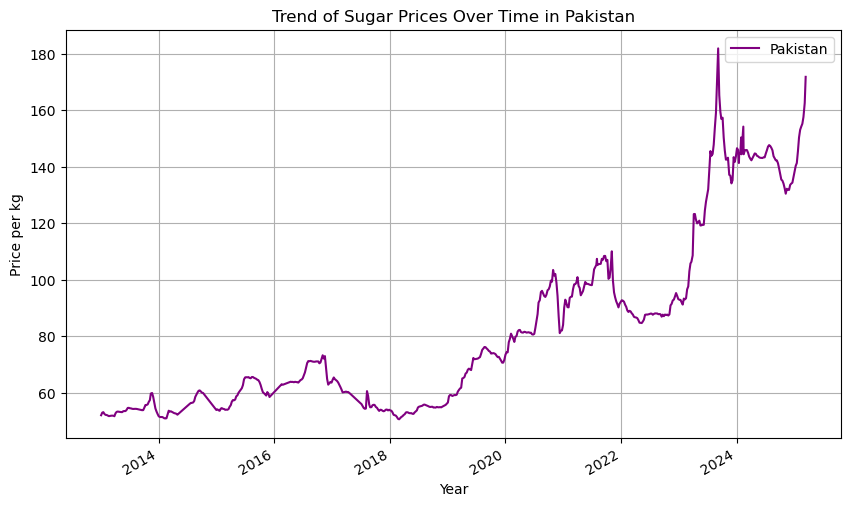

In [41]:
# Plot the 'Pakistan' column over time
suger_prices_2013_2025_pak_cleaned.plot(
    x='Period End',
    y='Pakistan',
    color='purple',
    legend=True,
    grid=True,
    title='Trend of Sugar Prices Over Time in Pakistan',
    xlabel='Year',
    ylabel='Price per kg',
    figsize=(10, 6)  # Adjust the figure size if needed
)

From 2013 to 2025, it van be seen that sugar prices have been consistently rising over time.
The sharp overall increase after 2020 could indicate economic changes like inflation, supply chain disruptions, or policy shifts.

In [45]:
# Group by Year and calculate mean, median, variance, and standard deviation
price_stats = suger_prices_2013_2025_pak_cleaned.groupby('Year')['Pakistan'].agg(['mean', 'median', 'var', 'std'])
price_stats = price_stats.reset_index()
# Display the results
print(price_stats)


    Year        mean   median         var        std
0   2013   53.961556   53.480    3.879827   1.969728
1   2014   54.991250   53.335   12.708915   3.564956
2   2015   59.759184   59.810   18.998333   4.358708
3   2016   67.343158   66.145   13.920498   3.731018
4   2017   57.616744   55.700   15.408437   3.925358
5   2018   53.798824   54.700    2.401179   1.549574
6   2019   68.531837   71.380   38.202232   6.180795
7   2020   86.327925   81.930   67.968598   8.244307
8   2021   98.818000   98.395   33.438000   5.782560
9   2022   88.731765   87.850    6.526431   2.554688
10  2023  129.027647  132.070  546.879982  23.385465
11  2024  142.114808  143.505   27.942606   5.286077
12  2025  153.251000  153.690   92.950766   9.641098


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

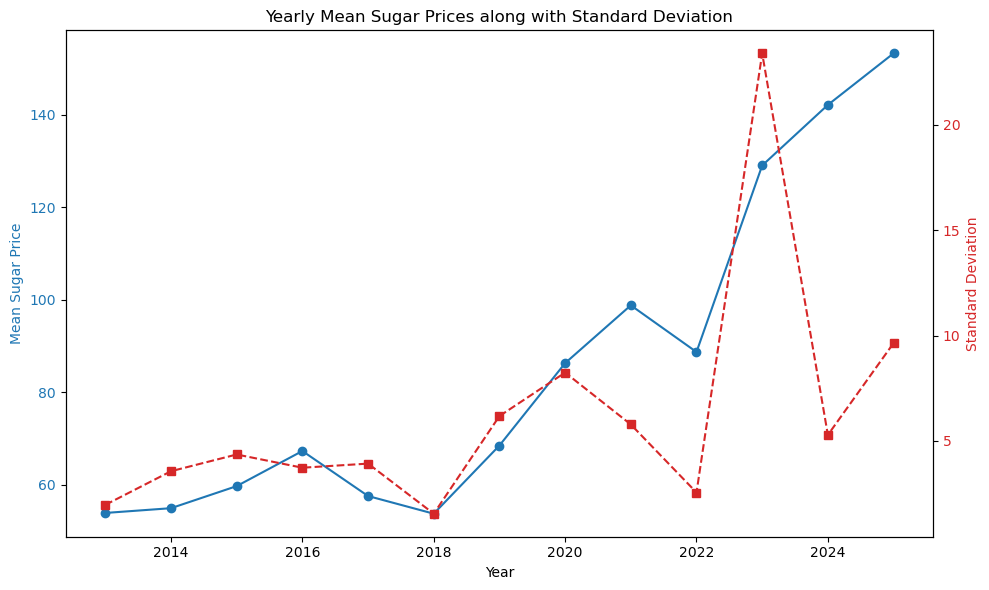

In [47]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# First y-axis (Mean Prices)
ax1.set_xlabel("Year")
ax1.set_ylabel("Mean Sugar Price", color="tab:blue")
ax1.plot(price_stats['Year'] , price_stats['mean'], marker="o", color="tab:blue", label="Mean Price per kg")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Second y-axis (Standard Deviation)
ax2 = ax1.twinx()
ax2.set_ylabel("Standard Deviation", color="tab:red")
ax2.plot(price_stats['Year'],price_stats['std'], marker="s", linestyle="dashed", color="tab:red", label="Std Deviation")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Titles & Legends
plt.title("Yearly Mean Sugar Prices along with Standard Deviation")
fig.tight_layout()
plt.show()

Before 2019, both the mean price and standard deviation were relatively low and stable. This suggests that sugar prices were more predictable in this period, with no major disruptions affecting supply or demand.

From 2020 to 2023, sugar prices significantly increased. Standard deviation peaked in 2023, indicating high price fluctuations (instability in sugar prices). Economic instability could be oone of the reasons affecting such commodity prices.

After 2023, standard deviation drops significantly, even though prices continue rising. This suggests that sugar prices are increasing more steadily, without extreme fluctuations. It could indicate market stabilization due to better supply chain management, policy adjustments, or steady demand.



## Visulaizing the monthly trend of sugar prices in Pakistan by Year

C:\Users\Admin\AppData\Local\Temp\ipykernel_37168\3019529145.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yearly_sugar_prices_pk['Month'] = pd.Categorical(yearly_sugar_prices_pk['Month'], categories=month_order, ordered=True)


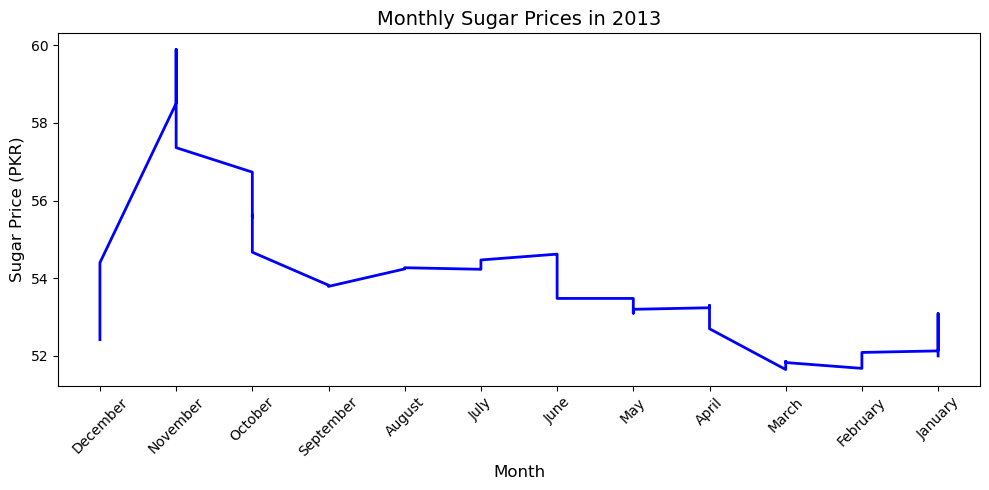

C:\Users\Admin\AppData\Local\Temp\ipykernel_37168\3019529145.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yearly_sugar_prices_pk['Month'] = pd.Categorical(yearly_sugar_prices_pk['Month'], categories=month_order, ordered=True)


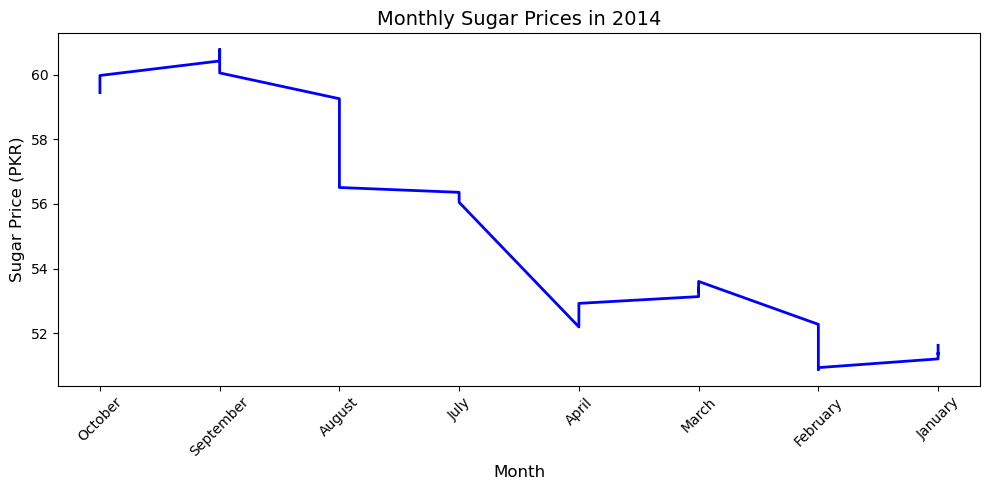

C:\Users\Admin\AppData\Local\Temp\ipykernel_37168\3019529145.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yearly_sugar_prices_pk['Month'] = pd.Categorical(yearly_sugar_prices_pk['Month'], categories=month_order, ordered=True)


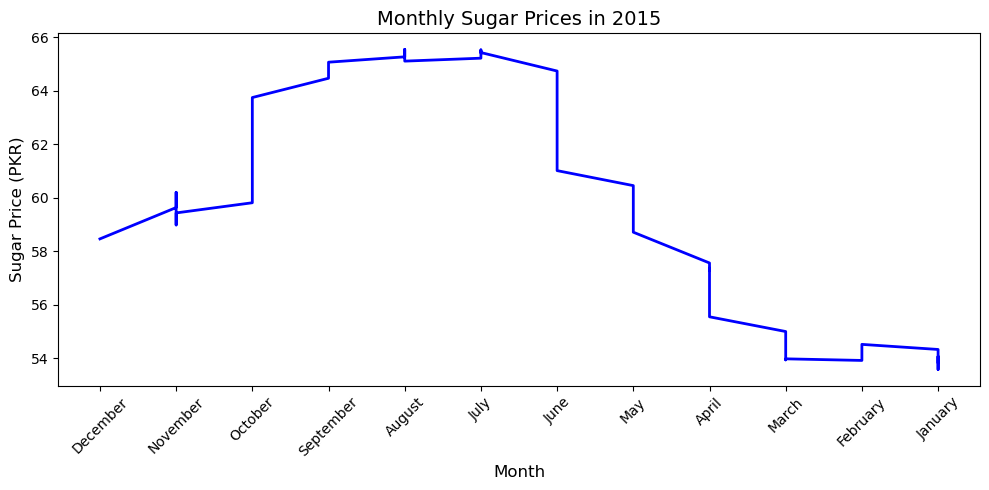

C:\Users\Admin\AppData\Local\Temp\ipykernel_37168\3019529145.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yearly_sugar_prices_pk['Month'] = pd.Categorical(yearly_sugar_prices_pk['Month'], categories=month_order, ordered=True)


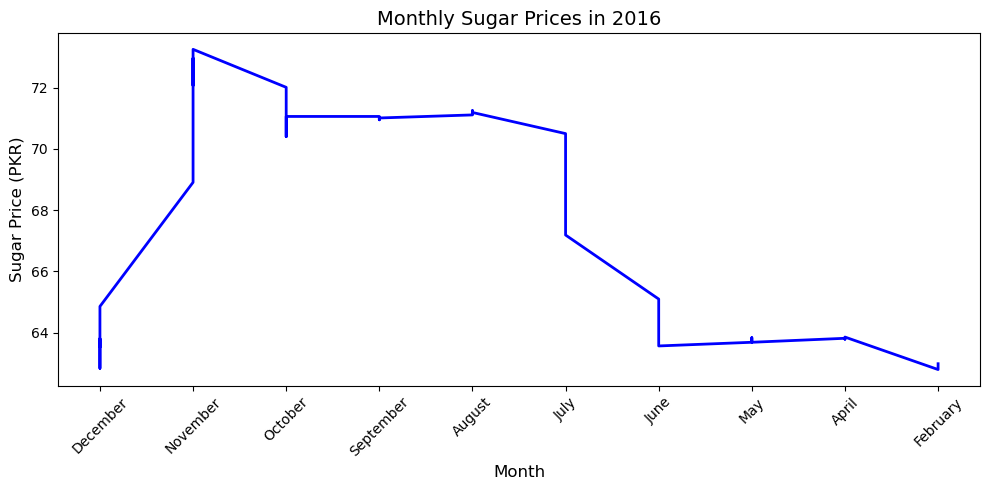

C:\Users\Admin\AppData\Local\Temp\ipykernel_37168\3019529145.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yearly_sugar_prices_pk['Month'] = pd.Categorical(yearly_sugar_prices_pk['Month'], categories=month_order, ordered=True)


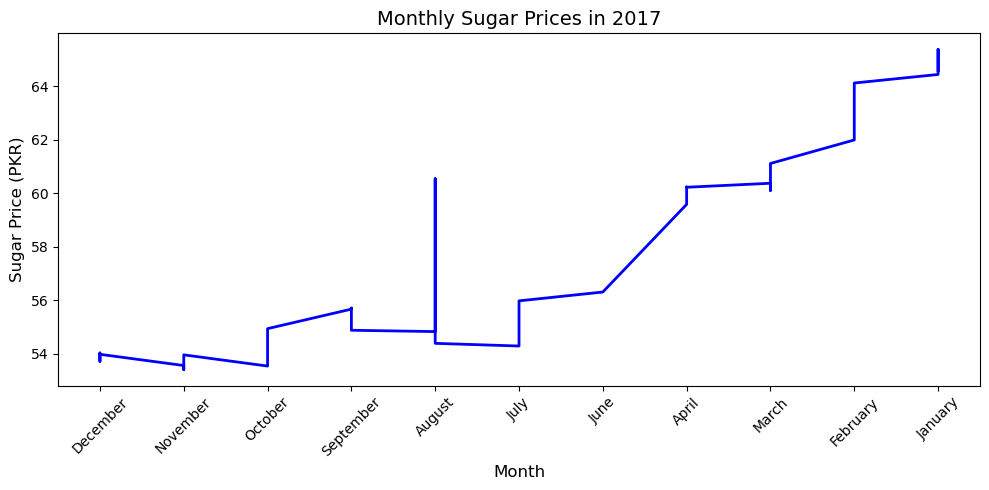

C:\Users\Admin\AppData\Local\Temp\ipykernel_37168\3019529145.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yearly_sugar_prices_pk['Month'] = pd.Categorical(yearly_sugar_prices_pk['Month'], categories=month_order, ordered=True)


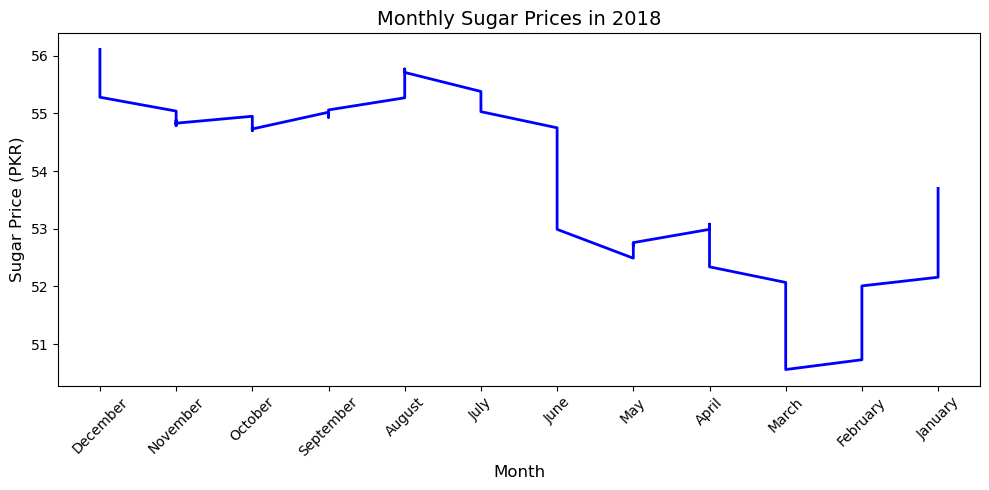

C:\Users\Admin\AppData\Local\Temp\ipykernel_37168\3019529145.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yearly_sugar_prices_pk['Month'] = pd.Categorical(yearly_sugar_prices_pk['Month'], categories=month_order, ordered=True)


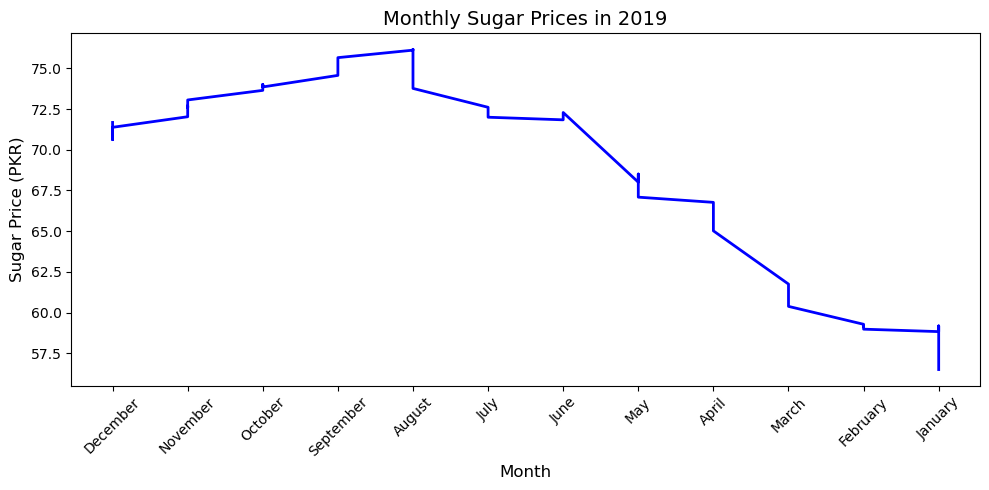

C:\Users\Admin\AppData\Local\Temp\ipykernel_37168\3019529145.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yearly_sugar_prices_pk['Month'] = pd.Categorical(yearly_sugar_prices_pk['Month'], categories=month_order, ordered=True)


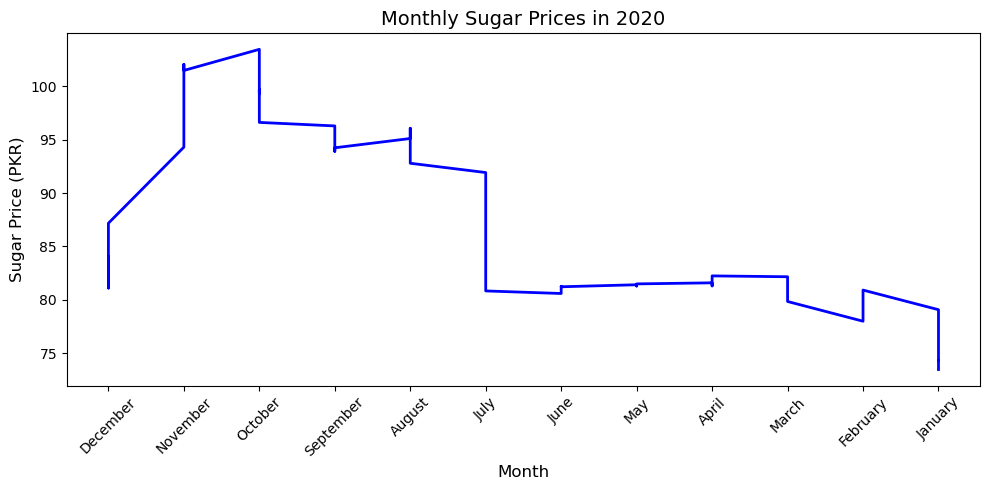

C:\Users\Admin\AppData\Local\Temp\ipykernel_37168\3019529145.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yearly_sugar_prices_pk['Month'] = pd.Categorical(yearly_sugar_prices_pk['Month'], categories=month_order, ordered=True)


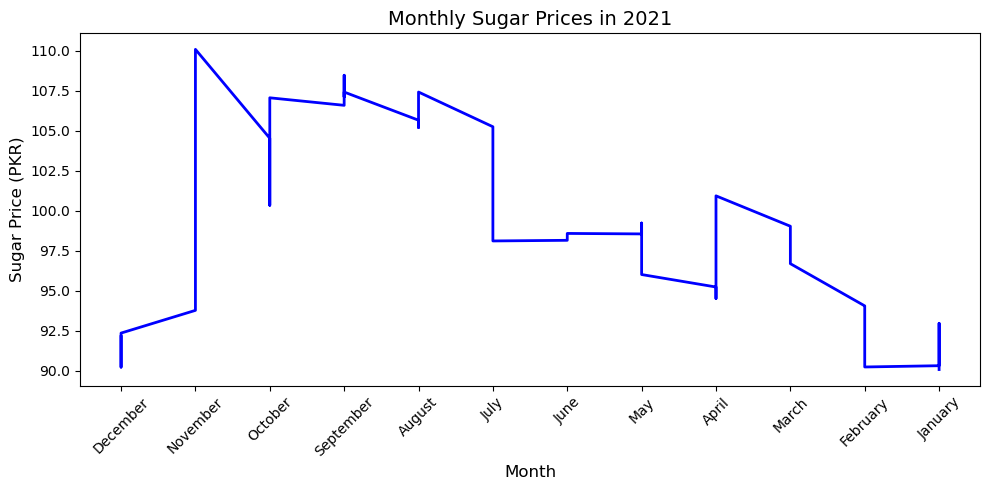

C:\Users\Admin\AppData\Local\Temp\ipykernel_37168\3019529145.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yearly_sugar_prices_pk['Month'] = pd.Categorical(yearly_sugar_prices_pk['Month'], categories=month_order, ordered=True)


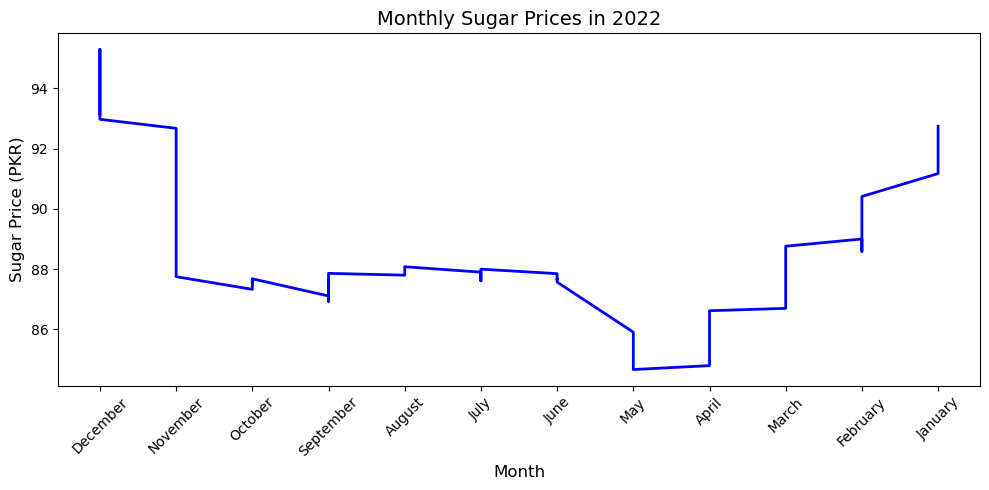

C:\Users\Admin\AppData\Local\Temp\ipykernel_37168\3019529145.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yearly_sugar_prices_pk['Month'] = pd.Categorical(yearly_sugar_prices_pk['Month'], categories=month_order, ordered=True)


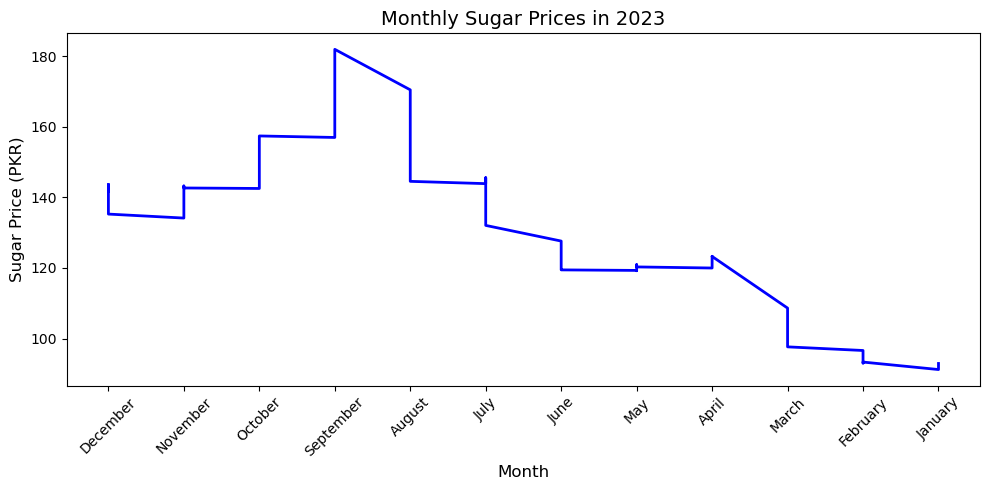

C:\Users\Admin\AppData\Local\Temp\ipykernel_37168\3019529145.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yearly_sugar_prices_pk['Month'] = pd.Categorical(yearly_sugar_prices_pk['Month'], categories=month_order, ordered=True)


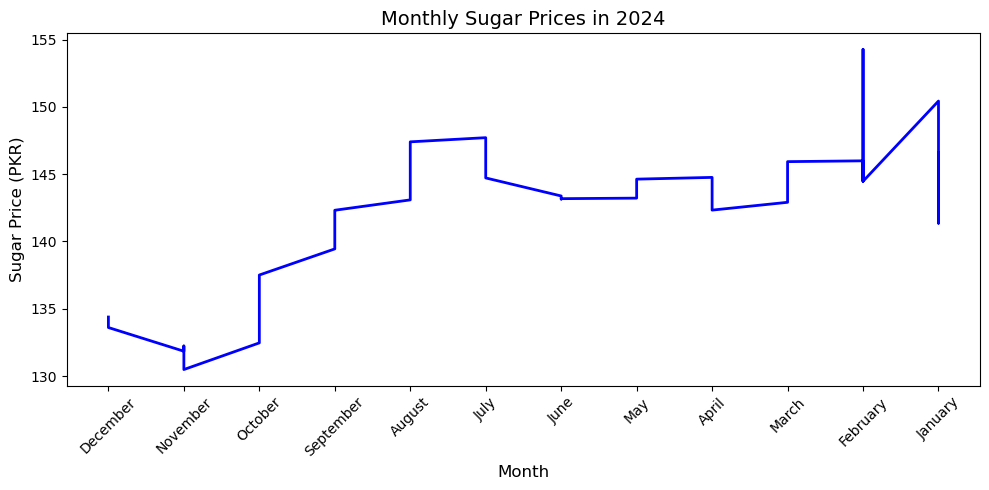

In [204]:
# Create a custom order for months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

for year in range(2013, 2025):
    # Filter the data for the specific year
    yearly_sugar_prices_pk = suger_prices_2013_2025_pak_cleaned[suger_prices_2013_2025_pak_cleaned['Year'] == year]

    # Convert 'Month' to a categorical type with the specified order
    yearly_sugar_prices_pk['Month'] = pd.Categorical(yearly_sugar_prices_pk['Month'], categories=month_order, ordered=True)

    # Sort the DataFrame by the ordered 'Month' column
    yearly_sugar_prices_pk = yearly_sugar_prices_pk.sort_values('Month')

    # Set up the figure and axes
    plt.figure(figsize=(10, 5))

    # Plot the line graph with a solid color
    plt.plot(yearly_sugar_prices_pk['Month Name'], yearly_sugar_prices_pk['Pakistan'], color='blue', linewidth=2)

    # # Generate rainbow colors for the line segments based on the number of months
    # colors = plt.cm.rainbow(np.linspace(0, 1, len(yearly_sugar_prices_pk)))

    # # Plot the line graph with rainbow-colored segments
    # for i in range(1, len(yearly_sugar_prices_pk)):
    #     plt.plot(yearly_sugar_prices_pk['Month Name'].iloc[i-1:i+1], yearly_sugar_prices_pk['Pakistan'].iloc[i-1:i+1],
    #              color=colors[i-1], linewidth=2)

    # Add values on each month point
    # for i, (month, price) in enumerate(zip(yearly_sugar_prices_pk['Month'], yearly_sugar_prices_pk['Pakistan'])):
    #     plt.text(i, price, f'{price:.2f}', ha='center', va='bottom', fontsize=10)

    # Set the title and labels
    plt.title(f'Monthly Sugar Prices in {year}', fontsize=14)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Sugar Price (PKR)', fontsize=12)

    # Rotate month names for better readability
    plt.xticks(rotation=45)

    # Display the plot
    plt.tight_layout()
    plt.show()


## Yearly distribution of sugar prices in Pakistan along with outlier detection

C:\Users\Admin\AppData\Local\Temp\ipykernel_37168\1014421005.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='Pakistan', data=suger_prices_2013_2025_pak_cleaned, palette='plasma')


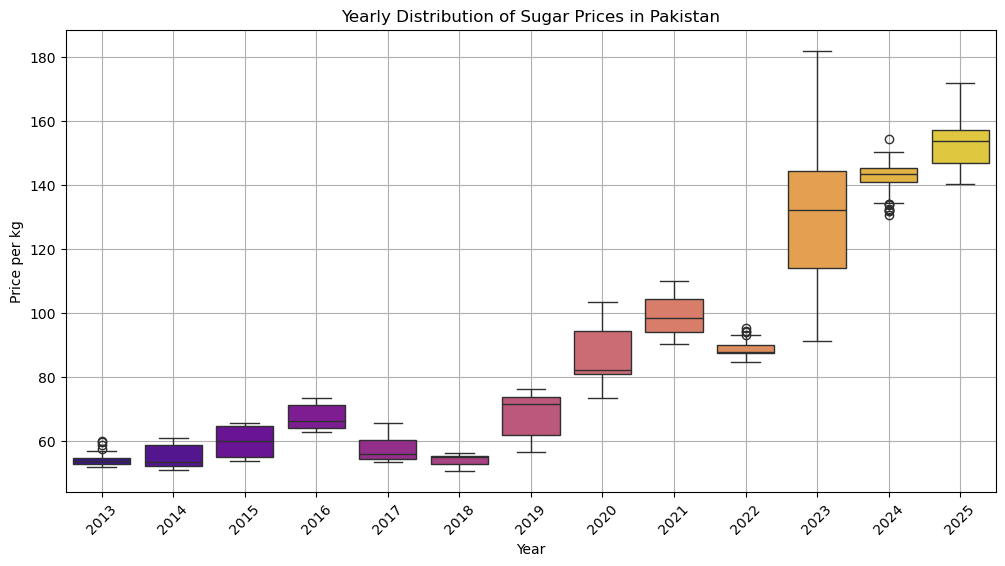

In [206]:
#outlier detection

suger_prices_2013_2025_pak_cleaned['Year'] = pd.to_datetime(suger_prices_2013_2025_pak_cleaned['Period End']).dt.year
plt.figure(figsize=(12, 6))
sns.boxplot(x='Year', y='Pakistan', data=suger_prices_2013_2025_pak_cleaned, palette='plasma')
plt.xticks(rotation=45)
plt.title('Yearly Distribution of Sugar Prices in Pakistan')
plt.xlabel('Year')
plt.ylabel('Price per kg')
plt.grid(True)
plt.show()


Prices were relatively stable from 2013 to 2018, as the IQRs are smaller.

Volatility starts increasing from 2019 onwards (with the exception fo 2022 and 2024), with 2023 showing the highest price fluctuation, suggesting market instability, supply chain disruptions, or policy impacts.

There are some points above the upper whisker, indicating that in 2022, there were some significantly high sugar prices compared to the general distribution of that year.

Unlike 2023, where there was a wider spread of prices, 2024 seems to have a more consistent price range. There were notable price drops (outliers below the lower whisker), which could indicate occasional downward price corrections. The majority of prices remain in a higher range, suggesting that sugar prices in 2024 were still elevated compared to previous years.

In [49]:
suger_prices_2013_2025_pak_cleaned.head()

,Period End,Islamabad,Rawalpindi,Gujranwala,Sialkot,Lahore,Faisalabad,Sargodha,Multan,Bahawalpur,...,Sukkur,Larkana,Peshawar,Bannu,Quetta,Khuzdar,Pakistan,Year,Month,Month Name
1,2025-03-13,176.24,177.65,175.0,175.0,172.94,170.0,170.0,168.99,170.00,...,168.0,168.32,171.10,170.0,174.49,170.67,171.90,2025,3,March
2,2025-03-07,169.41,169.66,165.0,165.0,163.32,160.0,160.0,158.99,160.00,...,158.0,158.32,166.65,160.0,165.99,162.65,162.64,2025,3,March
3,2025-02-27,163.74,161.65,160.0,160.0,160.00,155.0,155.0,156.42,155.00,...,155.0,153.32,160.55,155.0,158.99,157.65,157.68,2025,2,February
4,2025-02-20,161.24,159.66,155.0,158.0,156.41,155.0,155.0,154.20,153.32,...,150.0,150.00,160.55,155.0,157.49,155.99,155.27,2025,2,February
5,2025-02-13,158.74,158.65,160.0,160.0,156.41,150.0,152.0,154.20,151.65,...,150.0,150.00,156.65,150.0,154.99,155.99,154.27,2025,2,February


In [53]:
yearly_suger_prices_2013_2025_pak_cleaned = suger_prices_2013_2025_pak_cleaned[['Period End','Year', 'Month', 'Month Name', 'Pakistan' ]]
yearly_suger_prices_2013_2025_pak_cleaned.head()

,Period End,Year,Month,Month Name,Pakistan
1,2025-03-13,2025,3,March,171.90
2,2025-03-07,2025,3,March,162.64
3,2025-02-27,2025,2,February,157.68
4,2025-02-20,2025,2,February,155.27
5,2025-02-13,2025,2,February,154.27


In [54]:
yearly_suger_prices_2013_2025_pak_cleaned.dtypes

Period End    datetime64[ns]
Year                   int32
Month                  int32
Month Name            object
Pakistan             float64
dtype: object

In [55]:
yearly_suger_prices_2013_2025_pak_cleaned.describe()

,Period End,Year,Month,Pakistan
count,574,574.000000,574.000000,574.000000
mean,2019-05-29 13:30:18.815331072,2018.918118,6.395470,83.273589
min,2013-01-03 00:00:00,2013.000000,1.000000,50.560000
25%,2016-08-05 18:00:00,2016.000000,3.000000,55.807500
50%,2019-08-12 00:00:00,2019.000000,6.500000,72.440000
75%,2022-05-31 06:00:00,2022.000000,9.000000,96.665000
max,2025-03-13 00:00:00,2025.000000,12.000000,181.980000
std,NaN,3.483482,3.497002,31.645498


### Applying ARIMA

#### Checking for stationarity using ADF Test

In [58]:
# Imporitng the required libraries:

In [59]:
from statsmodels.tsa.stattools import adfuller

In [60]:
adf_result = adfuller(yearly_suger_prices_2013_2025_pak_cleaned['Pakistan'])

In [61]:
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])


ADF Statistic: -2.042512784585313
p-value: 0.26824924914209286


In [62]:
print('Critical Values:')
for key, value in adf_result[4].items():
    print(f'   {key}: {value}')

Critical Values:
   1%: -3.4419153151868147
   5%: -2.8666418984730146
   10%: -2.569487157434041


In [63]:
# if adf_result[1] <= 0.05:
#     print("The time series is likely stationary.")
# else:
#     print("The time series is likely non-stationary.")

if adf_result[1] <= 0.05:
    print("Strong evidence against the null hypothesis, reject the null hypothesis.The time series is likely stationary. ")
else:
    print("Weak evidence against null hypothesis, time series is likely non-stationary .")


Weak evidence against null hypothesis, time series is likely non-stationary .


#### Applying differencing to make the time series stationary:

In [65]:
prices = yearly_suger_prices_2013_2025_pak_cleaned['Pakistan']
period_end = yearly_suger_prices_2013_2025_pak_cleaned['Period End']

prices_diff = prices.diff().dropna()
period_end_for_diff = period_end[1:]  # Corresponding 'Period End' values

# Verify the lengths
print(f"Length of differenced prices: {len(prices_diff)}")
print(f"Length of corresponding Period End: {len(period_end_for_diff)}")

Length of differenced prices: 573
Length of corresponding Period End: 573


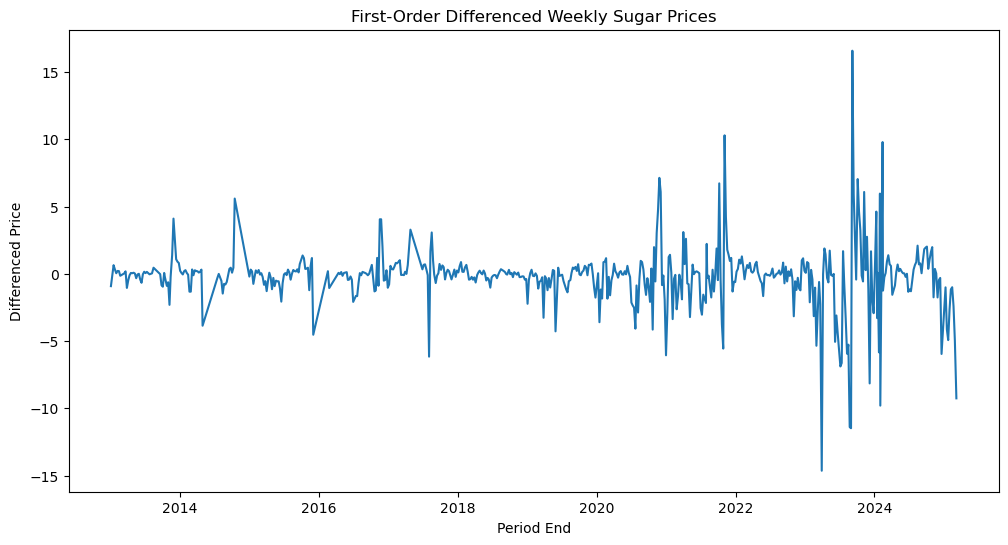

In [66]:
# Plot the differenced series
plt.figure(figsize=(12, 6))
plt.plot(period_end_for_diff, prices_diff)
plt.title('First-Order Differenced Weekly Sugar Prices')
plt.xlabel('Period End')
plt.ylabel('Differenced Price')
plt.show()

In [67]:
# Perform the ADF test on the differenced series
adf_result_diff = adfuller(prices_diff)
print('\nADF Statistic (Differenced):', adf_result_diff[0])
print('p-value (Differenced):', adf_result_diff[1])
print('Critical Values (Differenced):')
for key, value in adf_result_diff[4].items():
    print(f'   {key}: {value}')

if adf_result_diff[1] <= 0.05:
    print("The first-order differenced time series is likely stationary.")
else:
    print("The first-order differenced time series is likely non-stationary.")


ADF Statistic (Differenced): -9.621732761898885
p-value (Differenced): 1.7019084792975715e-16
Critical Values (Differenced):
   1%: -3.4419153151868147
   5%: -2.8666418984730146
   10%: -2.569487157434041
The first-order differenced time series is likely stationary.


#### Determine the order of the Autoregressive (AR) component (p) and the Moving Average (MA) component (q).

##### To do this, we will analyze the Autocorrelation Function (ACF) and the Partial Autocorrelation Function (PACF) plots of the first-order differenced stationary time series.

In [70]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

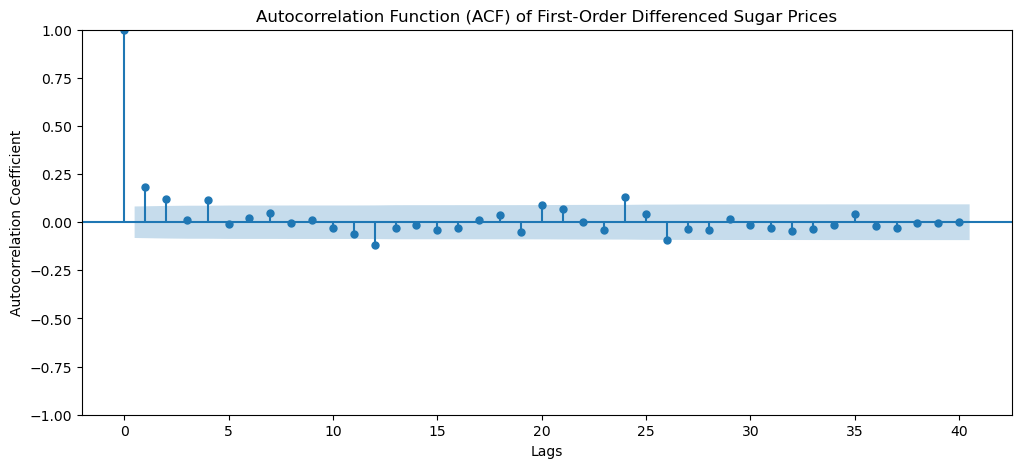

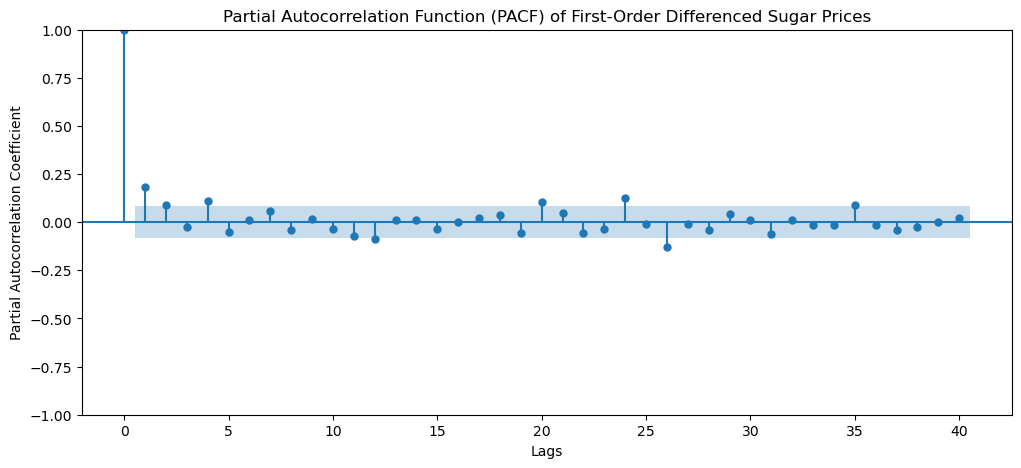

In [71]:
# Plot ACF
plt.figure(figsize=(12, 5))
plot_acf(prices_diff, lags=40, ax=plt.gca())  # You can adjust the number of lags
plt.title('Autocorrelation Function (ACF) of First-Order Differenced Sugar Prices')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation Coefficient')
plt.show()

# Plot PACF
plt.figure(figsize=(12, 5))
plot_pacf(prices_diff, lags=40, method='ywmle', ax=plt.gca()) # You can adjust the number of lags
plt.title('Partial Autocorrelation Function (PACF) of First-Order Differenced Sugar Prices')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation Coefficient')
plt.show()

#### Fitting the ARIMA(1, 1, 1) Model to the sugar price data based on a rolling window approach

In [75]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings

In [76]:
#Assuming yearly_suger_prices_2013_2025_pak_cleaned is a pandas Series or a list
data = yearly_suger_prices_2013_2025_pak_cleaned.dropna()
window_size = int(0.7 * len(data))
train_data = data[:window_size]

# Store forecasts and actual values
forecasted_prices = []
actual_prices = []

# The remaining 30% of the data will be our "future" for rolling prediction
n_predictions = len(data) - window_size

history = list(train_data['Pakistan'])

for i in range(n_predictions):
    try:
        # Fit the ARIMA(1,1,1) model
        # warnings filter to avoid showing convergence warnings
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            model = ARIMA(history, order=(1, 1, 1))
            model_fit = model.fit()

        # Make a one-step-ahead prediction
        output = model_fit.forecast()
        yhat = output[0]
        forecasted_prices.append(yhat)

        # Get the actual value for this time step
        obs = data[window_size + i]
        actual_prices.append(obs)

        # Add the predicted value to the history for the next iteration
        history.append(yhat)

        print(f"Iteration {i+1}: Forecast = {yhat:.2f}, Actual = {obs:.2f}") # Added for clarity

    except Exception as e:
        print(f"Error at iteration {i+1}: {e}")
        # You might want to handle the error differently, e.g.,
        # - Use a simple prediction (like the last actual value)
        # - Skip this iteration
        # - Stop the loop
        break  # I'll stop the loop for this example, but you can change it

print("Forecasted Prices:", forecasted_prices)
print("Actual Prices:", actual_prices)

Error at iteration 1: 401
Forecasted Prices: [60.09137935595068]
Actual Prices: []


ACF of Residuals:

This plot shows the autocorrelation of the residuals at different lags.

Ideally, we want the residuals to be uncorrelated (white noise).

While most of the autocorrelations are within the confidence intervals, there is a significant spike at lag 1. This indicates that there's some remaining autocorrelation in the residuals that the ARIMA(1, 1, 1) model hasn't fully captured. This suggests the model could be improved.


PACF of Residuals:

This plot shows the partial autocorrelation of the residuals.
Similar to the ACF plot, there's a significant spike at lag 1, further confirming the presence of residual autocorrelation.

Histogram of Residuals:

This plot shows the distribution of the residuals.

The histogram is not bell-shaped, indicating that the residuals are not normally distributed. This confirms the result of the Jarque-Bera test in the model summary, which strongly rejected the null hypothesis of normality. The distribution appears to be skewed to the left and has heavier tails than a normal distribution.

Summary of Residual Analysis (Based on Model Fitted to Original Data):

Heteroskedasticity: Evident in the time series plot and confirmed by the Heteroskedasticity test.

Autocorrelation: Significant autocorrelation at lag 1, indicating that the ARIMA(1, 1, 1) model has not fully accounted for the short-term dependencies in the data.

Non-Normality: The residuals are not normally distributed, as shown by the histogram and the Jarque-Bera test.

In [79]:
data = yearly_suger_prices_2013_2025_pak_cleaned.dropna()
data_sorted_year = data.sort_values(by='Period End', ascending=True).reset_index().drop(columns=['index'])

window_size = int(0.7 * len(data))
n_predictions = len(data_sorted_year) - window_size
train_data = data_sorted_year[:window_size]
actual_prices = []
rolling_predictions_arima = []
Period_End=[]
train_prices = list(train_data['Pakistan'])
for i in range(n_predictions):
    train_window = train_prices[i:i + window_size]
    model = ARIMA(train_window, order=(1, 1, 1))  # Adjust the order as needed
    fitted_model = model.fit()
    forecast = fitted_model.forecast(steps=1)[0]
    train_prices.append(forecast)
    rolling_predictions_arima.append(forecast)
    actual = data_sorted_year['Pakistan'].iloc[window_size + i]
    period_end = data_sorted_year['Period End'].iloc[window_size + i]
    Period_End.append(period_end)
    actual_prices.append(actual)

rolling_predictions_arima = pd.Series(rolling_predictions_arima)
actual_prices = pd.Series(actual_prices)

# Calculate Mean Squared Error
mse_arima = mean_squared_error(actual_prices, rolling_predictions_arima)

# Create a DataFrame
forecast_df_ARIMA = pd.DataFrame({'Actual_Price': actual_prices, 'Forecasted_Price_ARIMA': rolling_predictions_arima})
forecast_df_ARIMA['MSE_ARIMA'] = mse_arima
forecast_df_ARIMA['Period End'] = Period_End

forecast_df_ARIMA = forecast_df_ARIMA[['Period End', 'Actual_Price', 'Forecasted_Price_ARIMA', 'MSE_ARIMA']]
print("\nForecast DataFrame:")
forecast_df_ARIMA.set_index("Period End", inplace=True)
forecast_df_ARIMA.head(40)


Forecast DataFrame:


,Actual_Price,Forecasted_Price_ARIMA,MSE_ARIMA
Period End,,,
2021-11-04,110.08,105.634345,932.662572
2021-11-11,99.79,106.110813,932.662572
2021-11-18,95.55,106.314871,932.662572
2021-11-25,93.76,106.402187,932.662572
2021-12-02,92.34,106.439535,932.662572
2021-12-09,91.39,106.455513,932.662572
2021-12-16,90.21,106.462350,932.662572
2021-12-23,91.53,106.465275,932.662572
2021-12-30,92.12,106.466527,932.662572


The results shown by ARIMA (1,1,1) are not accurate . We will focus on auto ARIMA for forecasting purposes

In [55]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [65]:
data_sorted_year = data.sort_values(by='Period End', ascending=True).reset_index(drop=True)
window_size = int(0.7 * len(data_sorted_year))
n_predictions = len(data_sorted_year) - window_size
print(f"Window Size: {window_size}")
print(f"Number of predictions: {n_predictions}")
# took 5.06 minutes to run 150 iterations
# 2.69 mins to return 100 predictions
# 7.89 minutes to run 150

Window Size: 401
Number of predictions: 173


In [150]:
# Finaal code Sun 11th May

# auto arima with sliding window using actual prices
# correct code with auto arima
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error
import time  # Import the time module

# Prepare data
data = yearly_suger_prices_2013_2025_pak_cleaned.dropna()
data_sorted_year = data.sort_values(by='Period End', ascending=True).reset_index(drop=True)

window_size = int(0.7 * len(data_sorted_year))
n_predictions = len(data_sorted_year) - window_size

train_window = list(data_sorted_year['Pakistan'].iloc[:window_size])
rolling_predictions_auto_arima = []
actual_prices = []
Period_End = []

start_time = time.time()  # Record the start time

for i in range(n_predictions):
    # Auto ARIMA on current window (disable stepwise for better accuracy but slower)
    model = auto_arima(train_window,
                       seasonal=False,
                       suppress_warnings=True,
                       error_action='ignore',
                       stepwise=True)  # or stepwise=False for exhaustive search

    # Forecast 1 step ahead
    forecast = model.predict(n_periods=1)[0]

    # Store forecast and actual
    actual = data_sorted_year['Pakistan'].iloc[window_size + i]
    rolling_predictions_auto_arima.append(forecast)
    actual_prices.append(actual)
    Period_End.append(data_sorted_year['Period End'].iloc[window_size + i])

    # Sliding window update: drop oldest, add forecast
    train_window.pop(0)
    train_window.append(actual)

end_time = time.time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
execution_time_min = execution_time / 60
# Final forecast evaluation
forecast_df_auto_arima = pd.DataFrame({
    'Period End': Period_End,
    'Actual_Price': actual_prices,
    'Forecasted_Price_AutoARIMA': rolling_predictions_auto_arima
})
forecast_df_auto_arima['MSE_AutoARIMA'] = mean_squared_error(
    forecast_df_auto_arima['Actual_Price'],
    forecast_df_auto_arima['Forecasted_Price_AutoARIMA']
)

forecast_df_auto_arima.set_index("Period End", inplace=True)
print(forecast_df_auto_arima.head(40))
print(f"Execution Time: {execution_time_min:.2f} minutes")  # Print the execution time


            Actual_Price  Forecasted_Price_AutoARIMA  MSE_AutoARIMA
Period End                                                         
2021-11-04        110.08                  106.104164      12.706436
2021-11-11         99.79                  112.918010      12.706436
2021-11-18         95.55                   97.318798      12.706436
2021-11-25         93.76                   93.424716      12.706436
2021-12-02         92.34                   94.632116      12.706436
2021-12-09         91.39                   91.955558      12.706436
2021-12-16         90.21                   91.131990      12.706436
2021-12-23         91.53                   89.888334      12.706436
2021-12-30         92.12                   91.886994      12.706436
2022-01-06         92.74                   92.279766      12.706436
2022-01-13         92.58                   92.908078      12.706436
2022-01-20         92.22                   92.536575      12.706436
2022-01-27         91.17                   92.12

In [152]:
forecast_df_auto_arima.tail(40)

,Actual_Price,Forecasted_Price_AutoARIMA,MSE_AutoARIMA
Period End,,,
2024-05-30,143.22,143.572878,12.706436
2024-06-06,143.18,143.294124,12.706436
2024-06-13,143.15,143.409719,12.706436
2024-06-20,143.38,143.303634,12.706436
2024-06-27,143.38,143.565809,12.706436
2024-07-04,144.72,143.589746,12.706436
2024-07-11,145.88,145.050178,12.706436
2024-07-18,147.18,146.626199,12.706436
2024-07-25,147.71,147.213845,12.706436


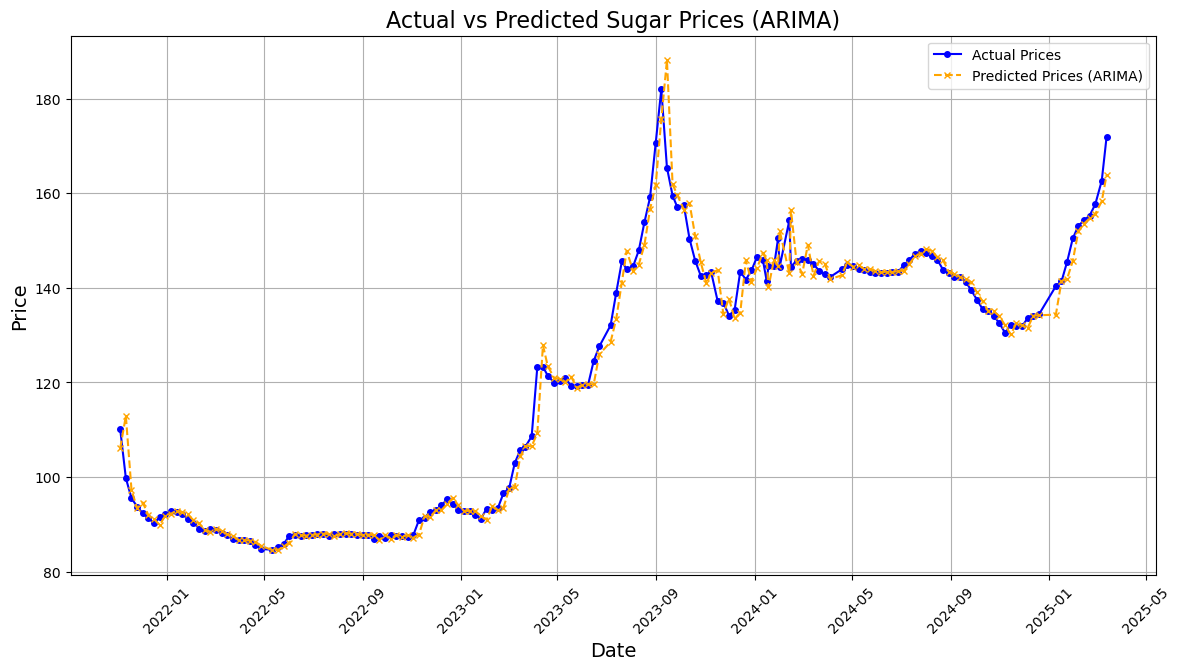

In [154]:
import matplotlib.pyplot as plt

# Plot the actual and predicted prices for ARIMA
plt.figure(figsize=(14, 7))
plt.plot(forecast_df_auto_arima.index, forecast_df_auto_arima['Actual_Price'],label='Actual Prices', color='blue', marker='o', markersize=4)
plt.plot(forecast_df_auto_arima.index, forecast_df_auto_arima['Forecasted_Price_AutoARIMA'], label='Predicted Prices (ARIMA)', color='orange', linestyle='--', marker='x', markersize=4)

# Adding title and labels
plt.title('Actual vs Predicted Sugar Prices (ARIMA)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# Show plot
plt.show()


## Exponential Smoothing:

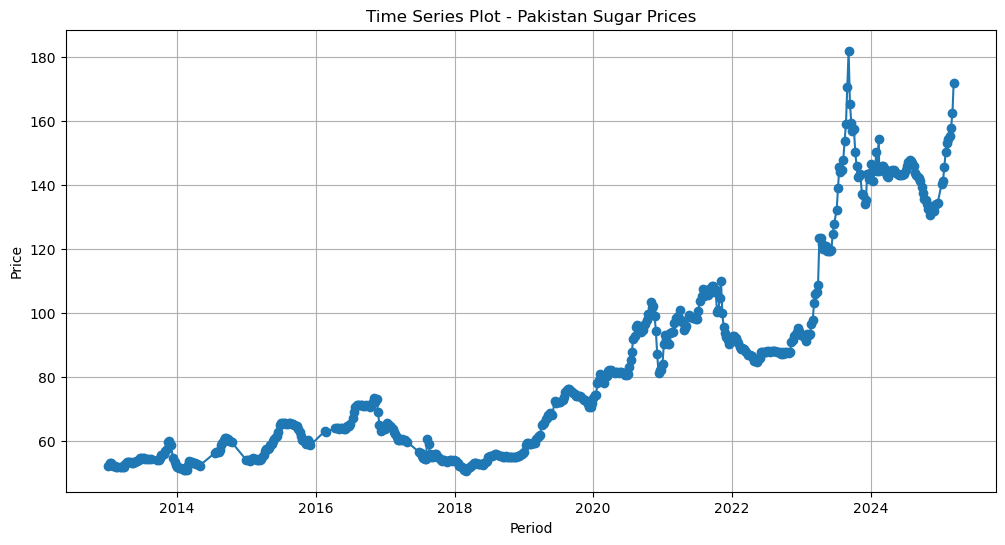

In [174]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(data_sorted_year['Period End'], data_sorted_year['Pakistan'], marker='o')
plt.title('Time Series Plot - Pakistan Sugar Prices')
plt.xlabel('Period')
plt.ylabel('Price')
plt.grid(True)
plt.show()


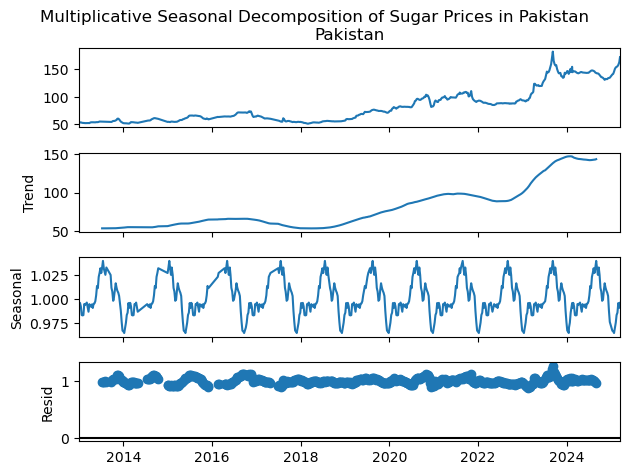

In [202]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt


# Prepare the time series
ts = data_sorted_year.set_index('Period End')['Pakistan']

# Perform additive seasonal decomposition
decomposition = seasonal_decompose(ts, model='multiplicative', period=52)  # Adjust period based on actual seasonality

# Plot the decomposition with a custom title
fig = decomposition.plot()
fig.suptitle('Multiplicative Seasonal Decomposition of Sugar Prices in Pakistan', fontsize=12)
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust top spacing to fit title
plt.show()



The seasonal component clearly shows a repeating pattern that occurs approximately every year

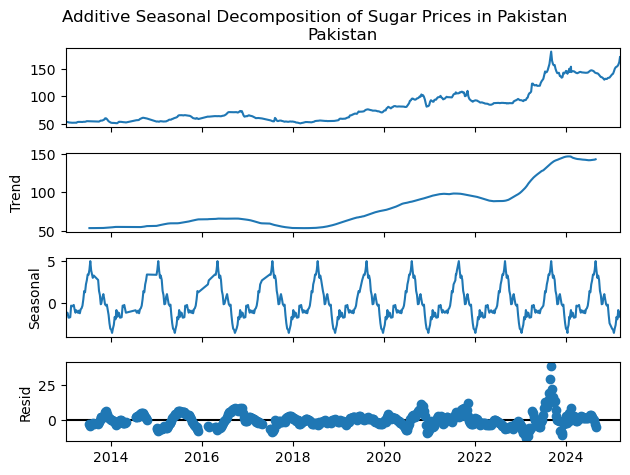

In [198]:
# import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Prepare the time series
ts = data_sorted_year.set_index('Period End')['Pakistan']

# Perform additive seasonal decomposition
decomposition = seasonal_decompose(ts, model='additive', period=52)  # Adjust period based on actual seasonality

# Plot the decomposition with a custom title
fig = decomposition.plot()
fig.suptitle('Additive Seasonal Decomposition of Sugar Prices in Pakistan', fontsize=12)
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust top spacing to fit title
plt.show()



In [73]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

ts = data_sorted_year.set_index('Period End')['Pakistan']

additive_result = seasonal_decompose(ts, model='additive', period=52)
multiplicative_result = seasonal_decompose(ts, model='multiplicative', period=52)

# Calculate standard deviation of residuals
additive_resid_std = additive_result.resid.dropna().std()
multiplicative_resid_std = multiplicative_result.resid.dropna().std()

print(f"Additive Residual Std Dev: {additive_resid_std:.4f}")
print(f"Multiplicative Residual Std Dev: {multiplicative_resid_std:.4f}")


Additive Residual Std Dev: 4.9336
Multiplicative Residual Std Dev: 0.0516


If the multiplicative residual standard deviation is much lower than the additive residual standard deviation, it suggests that the multiplicative model is capturing the variability of the data more effectively in relative terms (i.e., percentage errors are smaller).

Multiplicative models are often more suitable for data where the magnitude of the trend or seasonality changes over time in proportion to the level of the series (i.e., the size of fluctuations grows or shrinks with the level of the series).

In [222]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
import time

# Prepare data
data = yearly_suger_prices_2013_2025_pak_cleaned.dropna()
data_sorted_year = data.sort_values(by='Period End', ascending=True).reset_index(drop=True)

window_size = int(0.7 * len(data_sorted_year))
n_predictions = len(data_sorted_year) - window_size

train_window = list(data_sorted_year['Pakistan'].iloc[:window_size])
rolling_predictions_ets = []
actual_prices = []
Period_End = []

start_time = time.time()  # Start timer

for i in range(n_predictions):
    # Fit Exponential Smoothing (no trend/seasonality by default; change if needed)
    model = ExponentialSmoothing(train_window, trend='mul', seasonal='mul', seasonal_periods=12)
    model_fit = model.fit(optimized=True)

    # Forecast 1 step ahead
    forecast = model_fit.forecast(1)[0]

    # Store forecast and actual
    actual = data_sorted_year['Pakistan'].iloc[window_size + i]
    rolling_predictions_ets.append(forecast)
    actual_prices.append(actual)
    Period_End.append(data_sorted_year['Period End'].iloc[window_size + i])

    # Update sliding window
    train_window.pop(0)
    train_window.append(actual)

end_time = time.time()
execution_time_min = (end_time - start_time) / 60

# Final forecast evaluation
forecast_df_ets = pd.DataFrame({
    'Period End': Period_End,
    'Actual_Price': actual_prices,
    'Forecasted_Price_ETS': rolling_predictions_ets
})
forecast_df_ets['MSE_ETS'] = mean_squared_error(
    forecast_df_ets['Actual_Price'],
    forecast_df_ets['Forecasted_Price_ETS']
)

forecast_df_ets.set_index("Period End", inplace=True)
print(forecast_df_ets.head(40))
print(f"Execution Time: {execution_time_min:.2f} minutes")


C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:84: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:84: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:84: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:84: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:84: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:84: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:84: Runt

            Actual_Price  Forecasted_Price_ETS    MSE_ETS
Period End                                               
2021-11-04        110.08            104.120319  13.105844
2021-11-11         99.79            110.545305  13.105844
2021-11-18         95.55             99.548719  13.105844
2021-11-25         93.76             95.671499  13.105844
2021-12-02         92.34             94.047443  13.105844
2021-12-09         91.39             92.900743  13.105844
2021-12-16         90.21             91.814346  13.105844
2021-12-23         91.53             90.739143  13.105844
2021-12-30         92.12             91.893121  13.105844
2022-01-06         92.74             91.724680  13.105844
2022-01-13         92.58             92.635211  13.105844
2022-01-20         92.22             93.167147  13.105844
2022-01-27         91.17             92.216325  13.105844
2022-02-03         90.41             90.903727  13.105844
2022-02-10         89.12             89.970488  13.105844
2022-02-17    

In [224]:
forecast_df_ets.tail(40)

,Actual_Price,Forecasted_Price_ETS,MSE_ETS
Period End,,,
2024-05-30,143.22,143.780201,13.105844
2024-06-06,143.18,143.332483,13.105844
2024-06-13,143.15,143.049365,13.105844
2024-06-20,143.38,142.882747,13.105844
2024-06-27,143.38,143.279914,13.105844
2024-07-04,144.72,144.291632,13.105844
2024-07-11,145.88,145.911347,13.105844
2024-07-18,147.18,146.736670,13.105844
2024-07-25,147.71,147.685283,13.105844


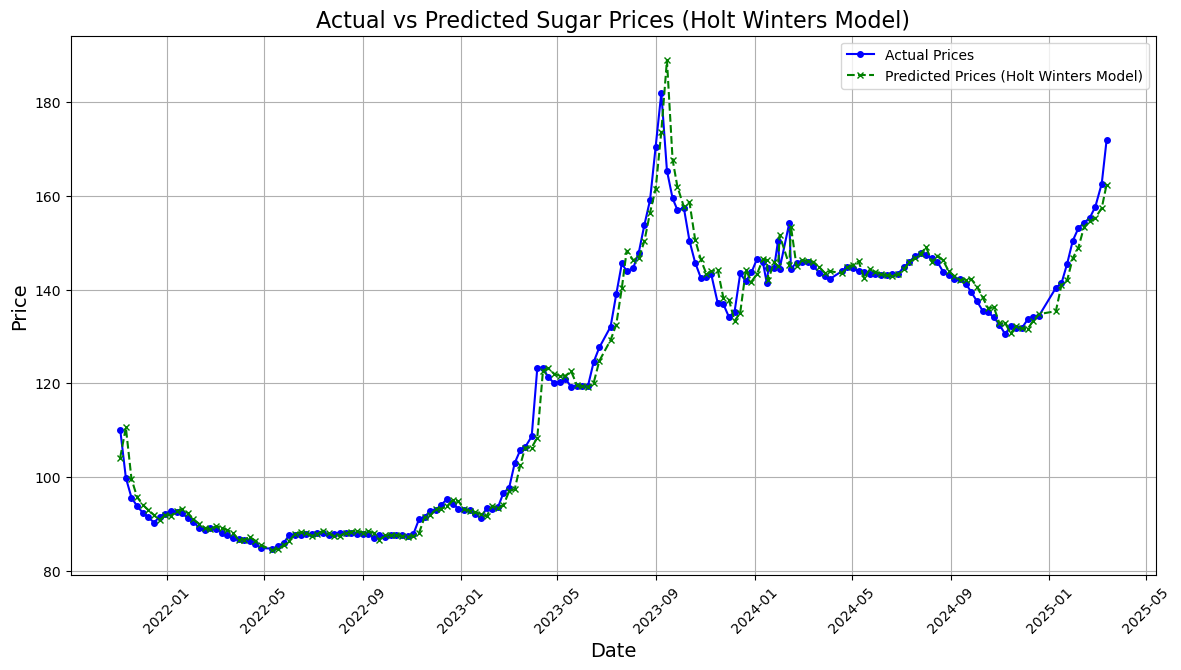

In [226]:
import matplotlib.pyplot as plt

# Plot the actual and predicted prices for Holt Winters model
plt.figure(figsize=(14, 7))
plt.plot(forecast_df_ets.index, forecast_df_ets['Actual_Price'],label='Actual Prices', color='blue', marker='o', markersize=4)
plt.plot(forecast_df_ets.index, forecast_df_ets['Forecasted_Price_ETS'], label='Predicted Prices (Holt Winters Model)', color='green', linestyle='--', marker='x', markersize=4)

# Adding title and labels
plt.title('Actual vs Predicted Sugar Prices (Holt Winters Model)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# Show plot
plt.show()


# Random Forest Regression

# 70% train, 30% test split


In [81]:
data_sorted_year.head()

,Period End,Year,Month,Month Name,Pakistan
0,2013-01-03,2013,1,January,52.00
1,2013-01-10,2013,1,January,52.92
2,2013-01-17,2013,1,January,53.09
3,2013-01-24,2013,1,January,52.45
4,2013-01-31,2013,1,January,52.13


In [83]:
suger_prices_2013_2025_pak.head()

,Period End,Islamabad,Rawalpindi,Gujranwala,Sialkot,Lahore,Faisalabad,Sargodha,Multan,Bahawalpur,Karachi,Hyderabad,Sukkur,Larkana,Peshawar,Bannu,Quetta,Khuzdar,Pakistan
0,Weekly,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR,PKR
1,13-Mar-2025,176.240000,177.650000,175,175,172.940000,170,170,168.990000,170,174.370000,170,168,168.320000,171.100000,170,174.490000,170.670000,171.900000
2,07-Mar-2025,169.410000,169.660000,165,165,163.320000,160,160,158.990000,160,162.540000,160,158,158.320000,166.650000,160,165.990000,162.650000,162.640000
3,27-Feb-2025,163.740000,161.650000,160,160,160,155,155,156.420000,155,157.100000,156.650000,155,153.320000,160.550000,155,158.990000,157.650000,157.680000
4,20-Feb-2025,161.240000,159.660000,155,158,156.410000,155,155,154.200000,153.320000,153.280000,150,150,150,160.550000,155,157.490000,155.990000,155.270000


In [93]:
# Prepare data

df = data_sorted_year

target_col = 'Pakistan'
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df[['Period End', target_col]].dropna()



In [95]:
def create_lag_features(df, target_col, lags=12):
    for lag in range(1, lags+1):
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    return df

lags = 12  # Use 12 previous periods
df_lagged = create_lag_features(df.copy(), target_col, lags)
df_lagged = df_lagged.dropna().reset_index(drop=True)



In [123]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

window_size = int(0.7 * len(df_lagged))
train_data = df_lagged[:window_size]
test_data = df_lagged[window_size:]

history = list(train_data[target_col])
forecasted_prices = []
actual_prices = []
forecast_dates = []

for i in range(len(test_data)):
    # Prepare lags for the current prediction
    lags_input = history[-12:]  # 12 lags
    X_pred = np.array(lags_input).reshape(1, -1)

    # Train model on all available history up to this point
    train_window = df_lagged.iloc[:window_size + i]
    X_train = train_window.drop(['Period End', target_col], axis=1)
    y_train = train_window[target_col]
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_pred)[0]
    forecasted_prices.append(y_pred)
    actual_prices.append(test_data[target_col].iloc[i])
    forecast_dates.append(test_data['Period End'].iloc[i])

    # Update history with actual value (for true rolling forecast)
    history.append(test_data[target_col].iloc[i])

# Convert results to DataFrame
results = pd.DataFrame({
    'Date': forecast_dates,
    'Actual': actual_prices,
    'Predicted': forecasted_prices
})

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:493: U

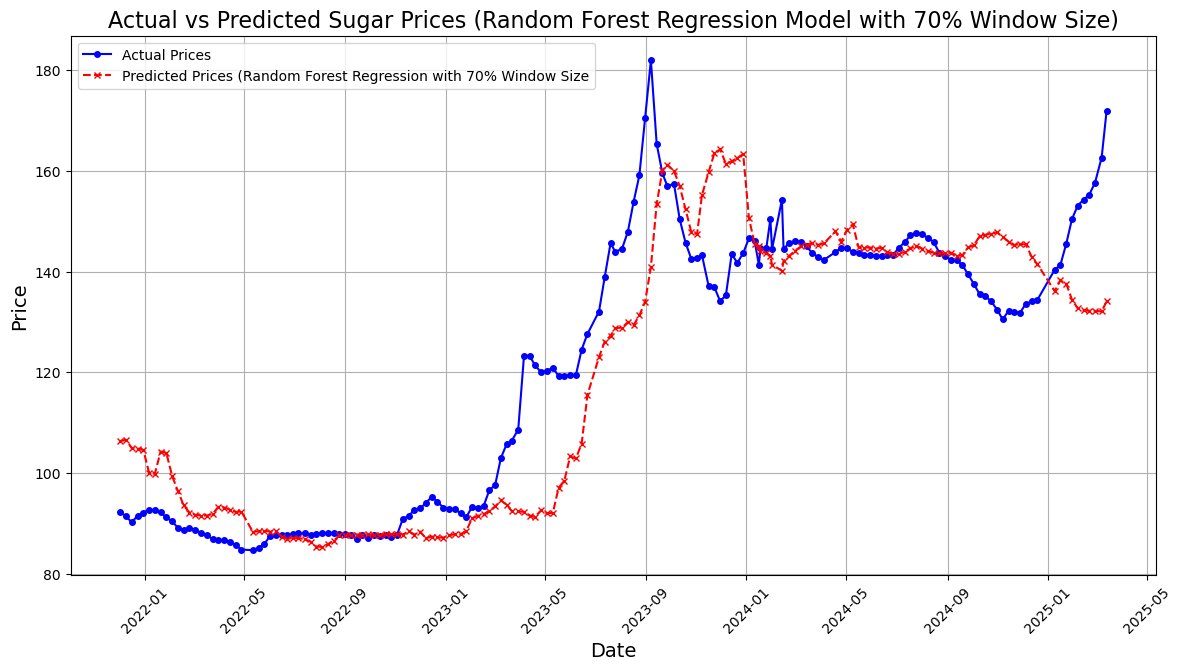

In [125]:
import matplotlib.pyplot as plt

# Plot the actual and predicted prices for Holt Winters model
plt.figure(figsize=(14, 7))
plt.plot(results['Date'], results['Actual'], label='Actual Prices', color='blue', marker='o', markersize=4)
plt.plot(results['Date'], results['Predicted'], label='Predicted Prices (Random Forest Regression with 70% Window Size', color='red', linestyle='--', marker='x', markersize=4)

# Adding title and labels
plt.title('Actual vs Predicted Sugar Prices (Random Forest Regression Model with 70% Window Size)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# Show plot
plt.show()



In [107]:
# Evaluation
rmse = np.sqrt(mean_squared_error(results['Actual'], results['Predicted']))
mae = mean_absolute_error(results['Actual'], results['Predicted'])
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')

RMSE: 12.75
MAE: 8.83


#Window Size 100


In [113]:
#Window Size 100

window_size = 100  # Number of samples in each training window
horizon = 1        # Forecast horizon (one step ahead)

preds_100 = []
actuals_100 = []
dates_100 = []

for i in range(window_size, len(df_lagged)):
    train = df_lagged.iloc[i-window_size:i]
    test = df_lagged.iloc[i:i+horizon]
    X_train = train.drop(['Period End', target_col], axis=1)
    y_train = train[target_col]
    X_test = test.drop(['Period End', target_col], axis=1)
    y_test = test[target_col]

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    preds_100.extend(y_pred)
    actuals_100.extend(y_test.values)
    dates_100.extend(test['Period End'].values)

# Convert results to DataFrame
results_100 = pd.DataFrame({'Date': dates, 'Actual': actuals, 'Predicted': preds})
results_100['Date'] = pd.to_datetime(results['Date'])





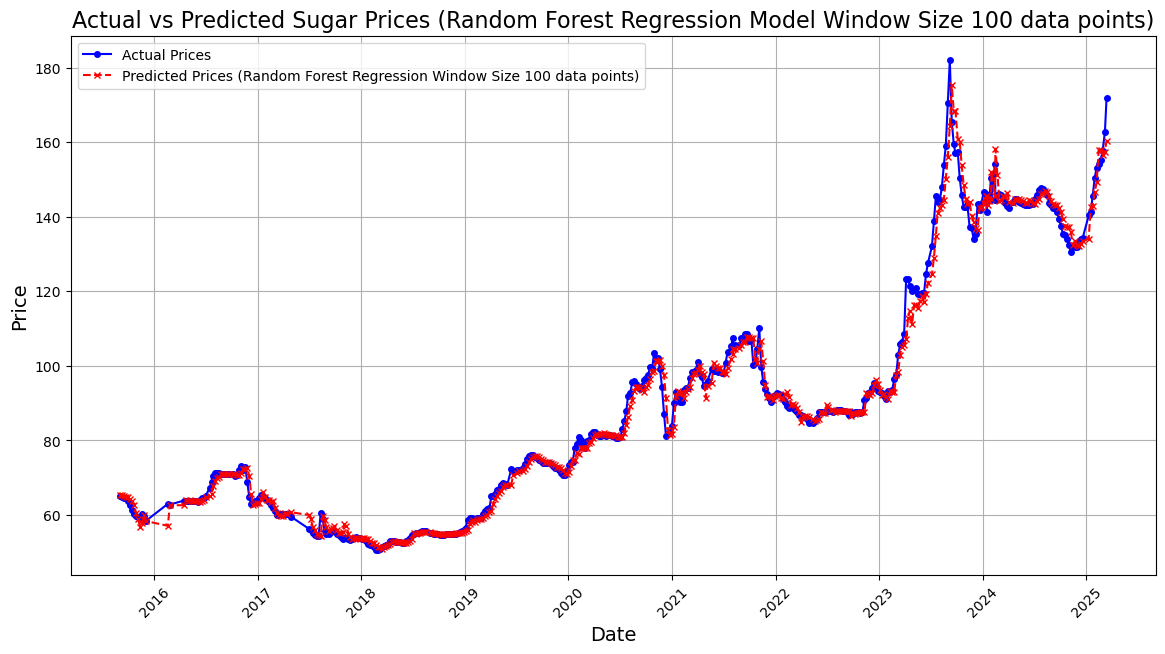

In [127]:
import matplotlib.pyplot as plt

# Plot the actual and predicted prices for Holt Winters model
plt.figure(figsize=(14, 7))
plt.plot(results_100['Date'], results_100['Actual'], label='Actual Prices', color='blue', marker='o', markersize=4)
plt.plot(results_100['Date'], results_100['Predicted'], label='Predicted Prices (Random Forest Regression Window Size 100 data points)', color='red', linestyle='--', marker='x', markersize=4)

# Adding title and labels
plt.title('Actual vs Predicted Sugar Prices (Random Forest Regression Model Window Size 100 data points)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# Show plot
plt.show()




In [131]:
# Evaluation
rmse = np.sqrt(mean_squared_error(results_100['Actual'], results_100['Predicted']))
mae = mean_absolute_error(results_100['Actual'], results_100['Predicted'])
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')

RMSE: 3.10
MAE: 1.84


# Checking for model accuracy

Maetrics :
Mean Absolute Error (MAE)

Mean Squared Error (MSE)

Root Mean Squared Error (RMSE)

Mean Absolute Percentage Error (MAPE)

In [133]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / np.clip(y_true, a_min=1e-10, a_max=None))) * 100

def evaluate_forecast(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(actual, predicted)
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape
    }


In [228]:
# Evaluate Holt-Winters
metrics_ets = evaluate_forecast(
    forecast_df_ets['Actual_Price'],
    forecast_df_ets['Forecasted_Price_ETS']
)

# Evaluate Auto ARIMA
metrics_arima = evaluate_forecast(
    forecast_df_auto_arima['Actual_Price'],
    forecast_df_auto_arima['Forecasted_Price_AutoARIMA']
)

# Evaluate Random Forest 70% data window size
metrics_rf70perc = evaluate_forecast(
    results['Actual'],
    results['Predicted']
)


# Evaluate Random Forest 100 data points window size
metrics_rf100_points = evaluate_forecast(
    results_100['Actual'],
    results_100['Predicted']
)


# Display comparison
print("Holt-Winters Model Accuracy:")
for k, v in metrics_ets.items():
    print(f"{k}: {v:.4f}")

print("\nAuto ARIMA Model Accuracy:")
for k, v in metrics_arima.items():
    print(f"{k}: {v:.4f}")

print("\nRandom Forest (70% data window size) Model Accuracy :")
for k, v in metrics_rf70perc.items():
    print(f"{k}: {v:.4f}")

print("\nRandom Forest (100 data points window size) Model Accuracy :")
for k, v in metrics_rf100_points.items():
    print(f"{k}: {v:.4f}")


Holt-Winters Model Accuracy:
MAE: 2.0779
MSE: 13.1058
RMSE: 3.6202
MAPE: 1.5911

Auto ARIMA Model Accuracy:
MAE: 1.9827
MSE: 12.7064
RMSE: 3.5646
MAPE: 1.5060

Random Forest (70% data window size) Model Accuracy :
MAE: 8.8257
MSE: 162.5990
RMSE: 12.7514
MAPE: 7.0306

Random Forest (100 data points window size) Model Accuracy :
MAE: 1.8427
MSE: 9.6057
RMSE: 3.0993
MAPE: 1.8642


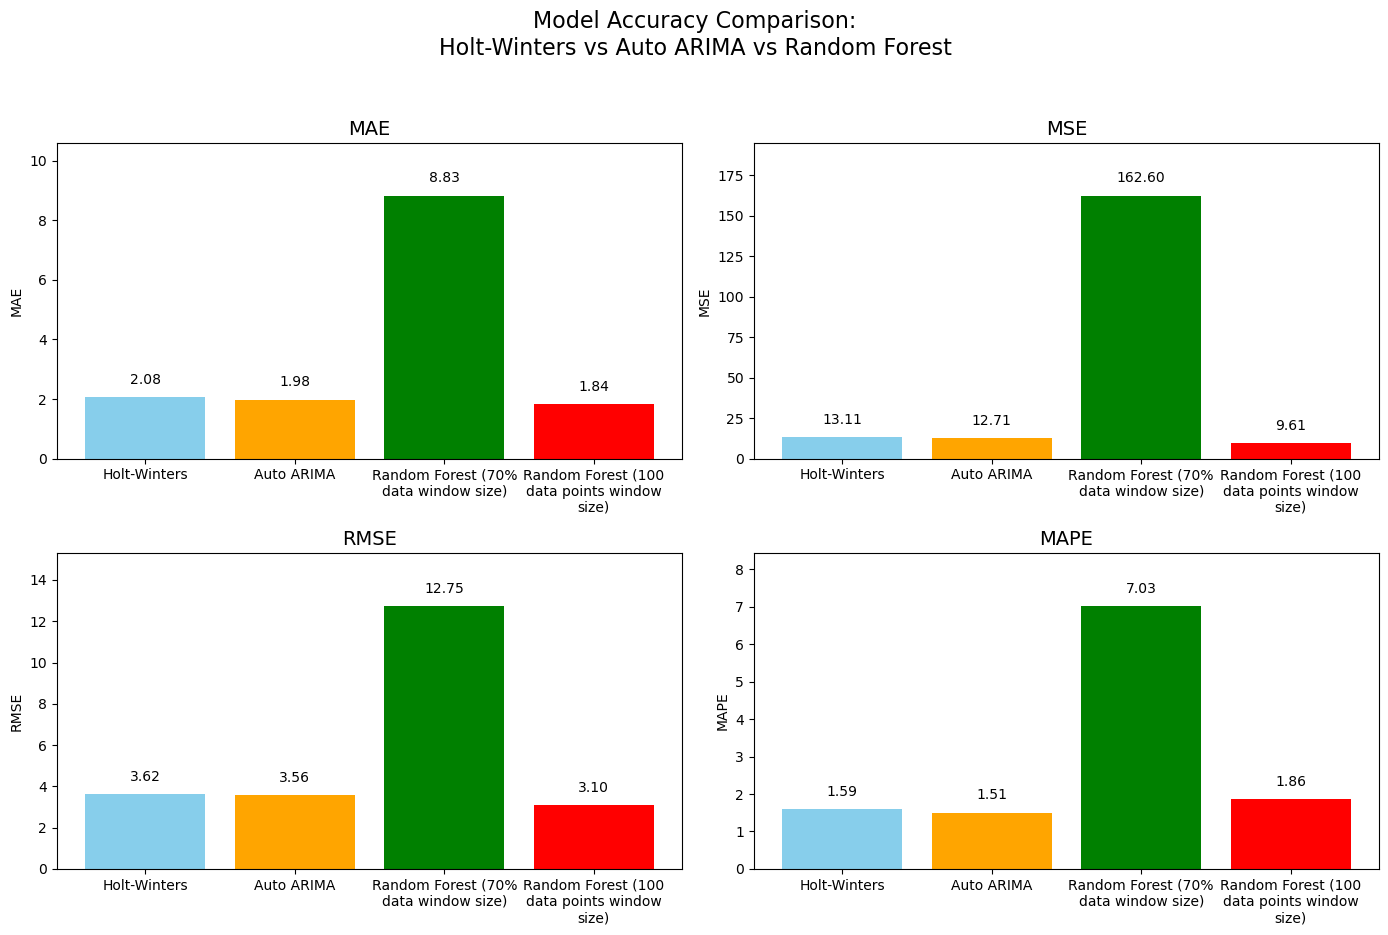

In [230]:
import matplotlib.pyplot as plt
import textwrap

# Combine metrics into a DataFrame
comparison_df = pd.DataFrame({
    'Holt-Winters': metrics_ets,
    'Auto ARIMA': metrics_arima,
    'Random Forest (70% data window size)': metrics_rf70perc,
    'Random Forest (100 data points window size)': metrics_rf100_points
})

# Colors for bars
bar_colors = ['skyblue', 'orange', 'green', 'red']

# Plot setup
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Model Accuracy Comparison:\nHolt-Winters vs Auto ARIMA vs Random Forest", fontsize=16)

# Flatten axes for easier indexing
axes = axes.flatten()
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE']

# Wrap long labels
wrapped_labels = [textwrap.fill(label, width=20) for label in comparison_df.columns]

for i, metric in enumerate(metrics):
    values = comparison_df.loc[metric]
    axes[i].bar(wrapped_labels, values, color=bar_colors)
    axes[i].set_title(metric, fontsize=14)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', labelrotation=0)
    axes[i].set_ylim(0, max(values) * 1.2)  # Add space for annotations

    # Annotate bars with metric values
    for idx, value in enumerate(values):
        axes[i].text(idx, value + max(values) * 0.05, f"{value:.2f}", ha='center', fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # Adjust layout to fit title
plt.show()


Best Overall Performer: Random Forest (100 data points window size)
Across all four evaluation metrics — MAE, MSE, RMSE, and MAPE — the Random Forest model with a 100-point window outperformed the others:

MAE: 1.84 (lowest)

MSE: 9.61 (lowest)

RMSE: 3.10 (lowest)

MAPE: 1.86% (lowest)

This indicates that the model:

Has very low prediction error (closer forecasts to actual values).

Handles non-linear patterns and short-term dependencies better than traditional time-series models.

Underperformer: Random Forest (70% window size)
This version of Random Forest showed significantly worse performance:

Highest MAE: 8.83

Highest MSE: 162.60

Highest RMSE: 12.75

Highest MAPE: 7.03%

This suggests that a large window size (70%) may cause overfitting or loss of sensitivity to recent trends in the data — highlighting the importance of window size tuning in time series-based machine learning.

Traditional Models: Holt-Winters vs Auto ARIMA
Both Holt-Winters and Auto ARIMA delivered moderate and comparable performance.

Auto ARIMA slightly outperforms Holt-Winters in:

MAE: 1.98 vs 2.02

MAPE: 1.53 vs 1.54

But Holt-Winters performs better in RMSE and MSE, indicating:

Holt-Winters may be more stable when larger errors occur.

Auto ARIMA is slightly more precise on average.

These models may still be suitable for seasonal and linear trends, especially when interpretability or computational simplicity is preferred.

Key Takeaways for Sugar Price Prediction

Random Forest (100-point window) is the most accurate model for this dataset, capturing complex patterns and delivering robust predictions.

Traditional models (Auto ARIMA & Holt-Winters) are still valid baselines and useful when simplicity, explainability, or faster deployment is needed.

Window size is critical in time series modeling — improper configuration (like 70% split) can degrade performance.

# Practical implications and trend analysis of the results

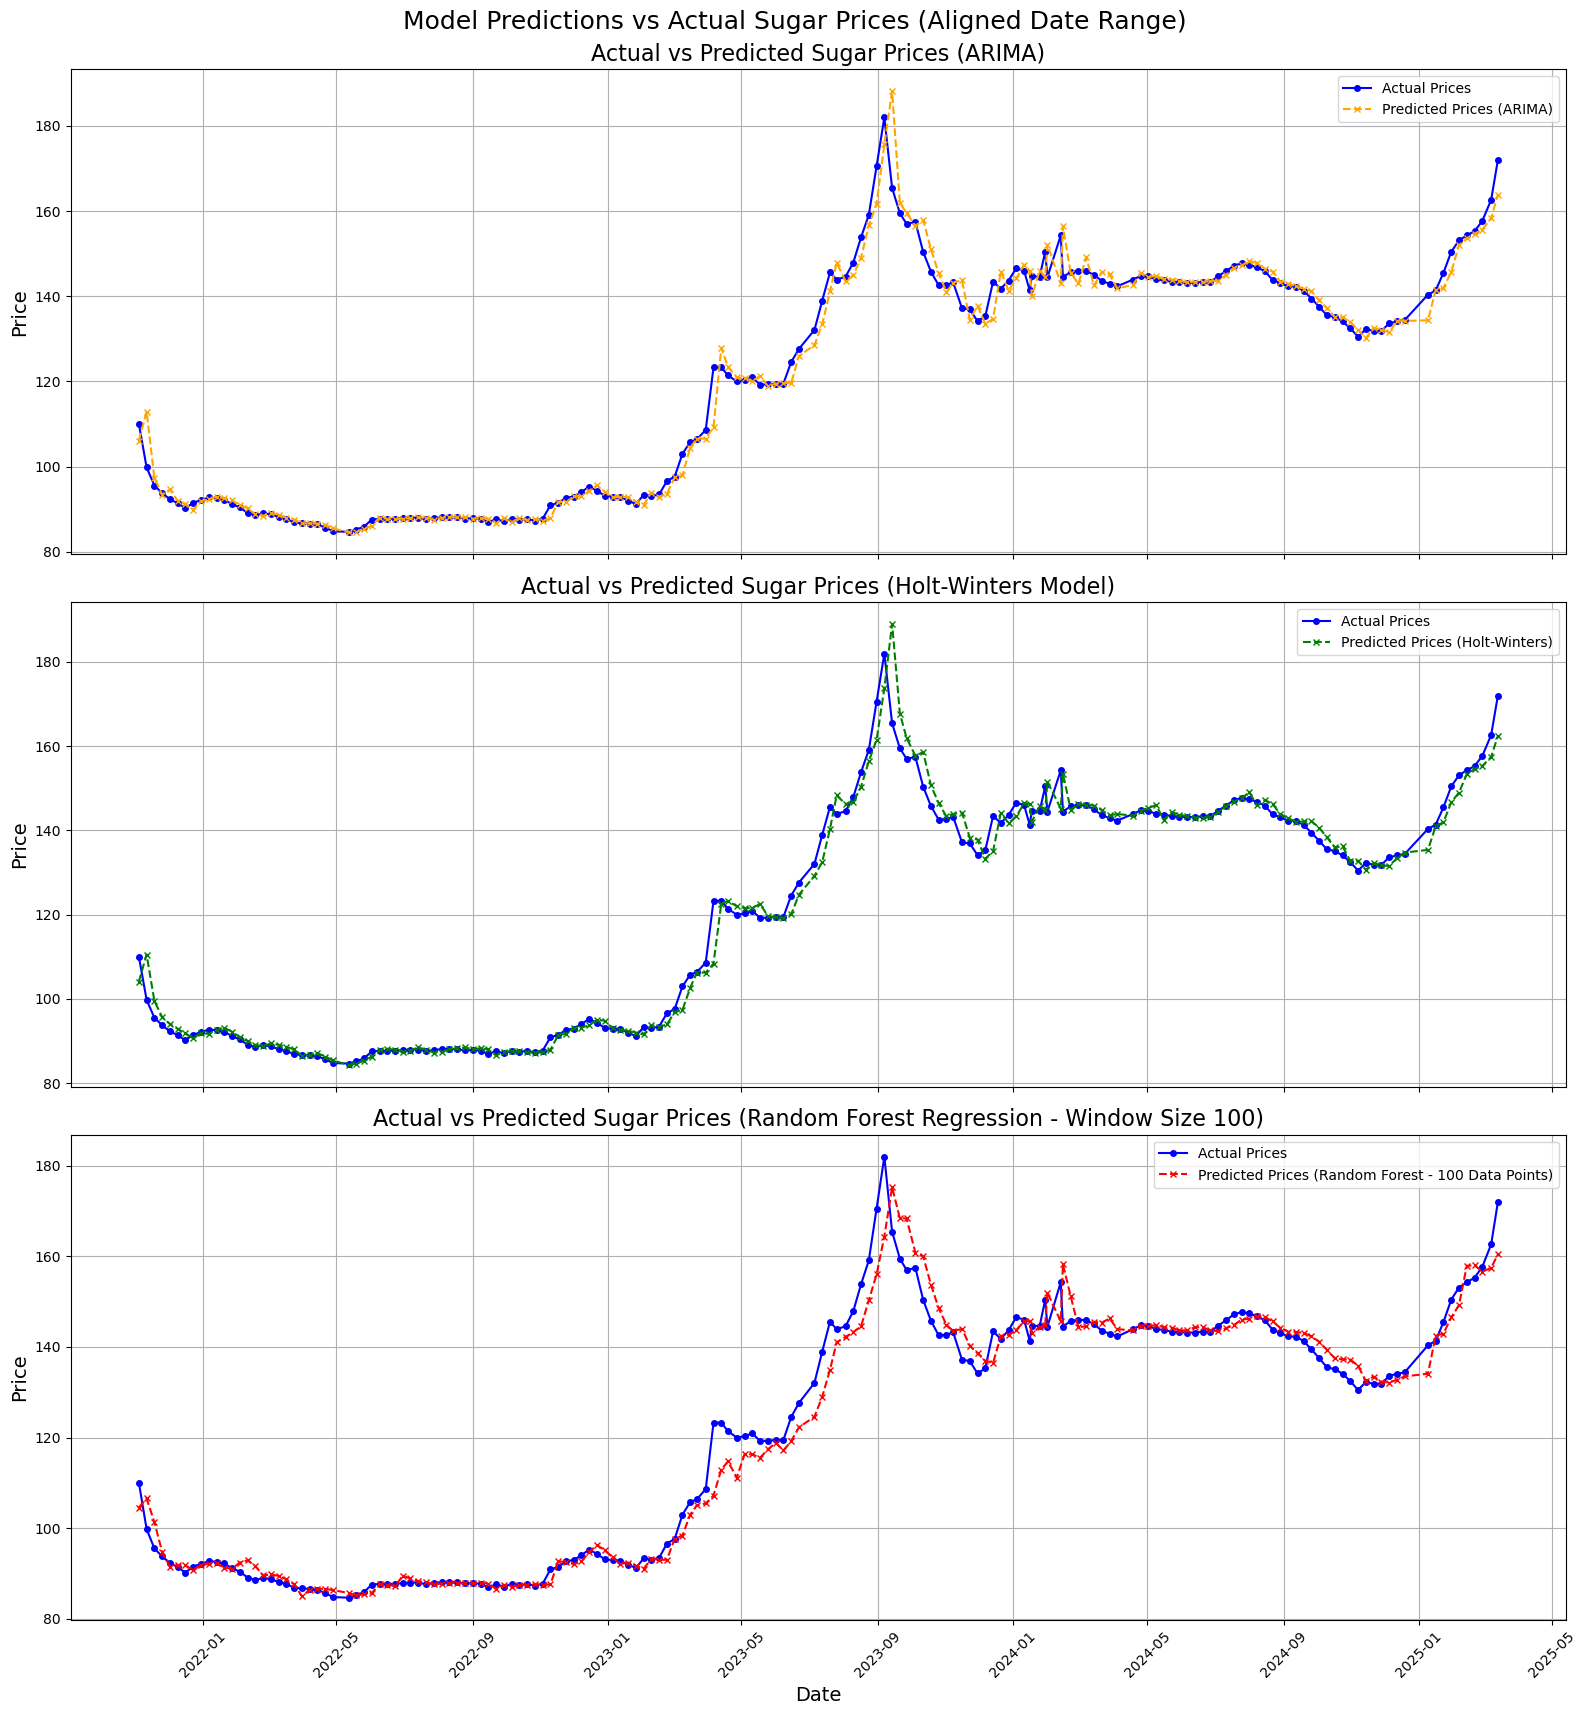

In [233]:
import matplotlib.pyplot as plt

# Step 1: Define date range based on Holt-Winters / Auto ARIMA
start_date = forecast_df_ets.index.min()
end_date = forecast_df_ets.index.max()

# Step 2: Filter Random Forest results to the same date range
results_100_filtered = results_100[
    (results_100['Date'] >= start_date) & (results_100['Date'] <= end_date)
]

# Step 3: Create the combined plot
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=True)

# --- Plot 1: Auto ARIMA ---
axes[0].plot(forecast_df_auto_arima.index, forecast_df_auto_arima['Actual_Price'], label='Actual Prices', color='blue', marker='o', markersize=4)
axes[0].plot(forecast_df_auto_arima.index, forecast_df_auto_arima['Forecasted_Price_AutoARIMA'], label='Predicted Prices (ARIMA)', color='orange', linestyle='--', marker='x', markersize=4)
axes[0].set_title('Actual vs Predicted Sugar Prices (ARIMA)', fontsize=16)
axes[0].set_ylabel('Price', fontsize=14)
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: Holt-Winters ---
axes[1].plot(forecast_df_ets.index, forecast_df_ets['Actual_Price'], label='Actual Prices', color='blue', marker='o', markersize=4)
axes[1].plot(forecast_df_ets.index, forecast_df_ets['Forecasted_Price_ETS'], label='Predicted Prices (Holt-Winters)', color='green', linestyle='--', marker='x', markersize=4)
axes[1].set_title('Actual vs Predicted Sugar Prices (Holt-Winters Model)', fontsize=16)
axes[1].set_ylabel('Price', fontsize=14)
axes[1].legend()
axes[1].grid(True)

# --- Plot 3: Random Forest (Filtered) ---
axes[2].plot(results_100_filtered['Date'], results_100_filtered['Actual'], label='Actual Prices', color='blue', marker='o', markersize=4)
axes[2].plot(results_100_filtered['Date'], results_100_filtered['Predicted'], label='Predicted Prices (Random Forest - 100 Data Points)', color='red', linestyle='--', marker='x', markersize=4)
axes[2].set_title('Actual vs Predicted Sugar Prices (Random Forest Regression - Window Size 100)', fontsize=16)
axes[2].set_xlabel('Date', fontsize=14)
axes[2].set_ylabel('Price', fontsize=14)
axes[2].legend()
axes[2].grid(True)

# Rotate x-axis ticks
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

# Layout and title
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.suptitle("Model Predictions vs Actual Sugar Prices (Aligned Date Range)", fontsize=18)
plt.show()


1. ARIMA Model

Chart (Top Panel):

The predicted values (orange) closely follow the actual values (blue) for most of the time series.

Strengths:

Performs well in stable trend regions.

Captures major upward and downward trends.

Weaknesses:

Slight lag in capturing sudden spikes, particularly during sharp increases or drops.

Appears less reactive to abrupt changes — expected from ARIMA’s reliance on past linear patterns and lag terms.

Holt-Winters Model
Chart (Middle Panel):

Shows a slightly delayed and dampened reaction to actual price spikes and drops.

Strengths:

Good at capturing seasonality and long-term trends.

Weaknesses:

Underestimates the magnitude of sharp price surges, especially around the 2020–2021 period.

Struggles in high-variance zones where sugar prices fluctuated abruptly.

Interpretation: While generally aligned with the trend, its smoothened predictions may overlook volatile behaviors — a limitation of exponential smoothing methods.

3. Random Forest Regression (Window Size 100)
Chart (Bottom Panel):

The closest match to actual sugar prices (red and blue lines nearly overlap).

Strengths:

Accurately captures peaks and troughs, even during volatile periods (e.g., mid-2020 to 2021).

Effectively adapts to non-linear patterns, including sudden trend shifts.

Weaknesses:

Slightly noisier than the other two models — some jitter may result from overfitting.

Interpretation: The Random Forest model generalizes better across all price patterns, including rapid fluctuations, thanks to its ability to model complex non-linear interactions.

# Future recommendations and policy implications

1. Government / Regulatory Bodies
Implication:

The consistent increase in sugar prices suggests inflationary pressure on essential commodities.

Actionable Policies:

Implement price controls or subsidies during peak price periods to protect low-income consumers.

Strengthen market surveillance to prevent hoarding or price manipulation by middlemen.

Create a buffer stock strategy by stockpiling sugar during low-price periods for release during price spikes.

2. Agricultural Sector (Sugarcane Farmers)

Implication:

Rising sugar prices may indicate an opportunity for increased profitability for farmers.

Actionable Policies:

Encourage higher sugarcane production through crop support programs and access to credit.

Provide forecasting tools to farmers to time planting/harvesting for maximum return.

Invest in climate-resilient crop varieties, since volatility may be linked to climate-driven yield shocks.

3. Industrial Sector (Food and Beverage Manufacturers)
Implication:

Sharp and unpredictable increases in sugar prices affect input costs and profit margins.

Actionable Policies:

Promote diversification of inputs (e.g., alternative sweeteners).

Offer tax incentives for firms investing in supply chain efficiency (storage, local sourcing).

Encourage adoption of long-term price contracts with suppliers to hedge against volatility.



 4. Retail Sector & Consumers

Implication:

Higher sugar prices can reduce consumer purchasing power and shift demand patterns.

Actionable Policies:

Support consumer awareness campaigns around smart purchasing and healthier alternatives.

Expand consumer assistance programs to offset rising household costs in low-income communities.

 5. Trade & Import Policy

Implication:

Price volatility may reflect local supply issues or global commodity price fluctuations.

Actionable Policies:

Adjust import tariffs during domestic shortages to stabilize prices.

Negotiate bilateral trade agreements with sugar-exporting countries to ensure supply stability.

Develop an early warning system using time series forecasting to anticipate and act on future price hikes.